In [4]:
import os
import pandas as pd
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Path to the parent directory (current folder in your case)
parent_dir = "."

# Loop through each folder in the parent directory
for folder in os.listdir(parent_dir):
    folder_path = os.path.join(parent_dir, folder)
    
    if os.path.isdir(folder_path):
        try:
            # Build file paths for the two Excel files
            suspended_file = os.path.join(folder_path, "ssd.xlsx")  # Suspended Sediment
            discharge_file = os.path.join(folder_path, "dis.xlsx")  # Discharge

            # Skip folder if files don't exist
            if not (os.path.exists(suspended_file) and os.path.exists(discharge_file)):
                continue

            # Load Excel files
            suspended_data = pd.read_excel(suspended_file, sheet_name=1, skiprows=10)
            discharge_data = pd.read_excel(discharge_file, sheet_name=1, skiprows=10)

            # Clean and rename columns
            suspended_clean = suspended_data.iloc[:, [2, 3]]
            suspended_clean.columns = ['Timestamp', 'Sediment_g_L']
            suspended_clean['Timestamp'] = pd.to_datetime(suspended_clean['Timestamp'], errors='coerce')

            discharge_clean = discharge_data.iloc[:, [2, 3]]
            discharge_clean.columns = ['Timestamp', 'Discharge_m3_s']
            discharge_clean['Timestamp'] = pd.to_datetime(discharge_clean['Timestamp'], errors='coerce')

            # Drop rows with invalid timestamps
            suspended_clean.dropna(subset=['Timestamp'], inplace=True)
            discharge_clean.dropna(subset=['Timestamp'], inplace=True)

            # Merge on exact timestamp match
            merged_df = pd.merge(discharge_clean, suspended_clean, on='Timestamp', how='inner')

            # Convert units: Sediment Load (tonne/day) = g/L * m3/s * 86.4
            merged_df['Sediment_tonne_day'] = merged_df['Sediment_g_L'] * merged_df['Discharge_m3_s'] * 86.4

            # Save the merged file with the folder name
            output_file = os.path.join(parent_dir, f"Merged_{folder}.csv")
            merged_df.to_csv(output_file, index=False)

            print(f"Merged file saved for folder: {folder}")

        except Exception:
            # Ignore all runtime errors and continue
            print(f"Error in: {folder}")
            pass

Merged file saved for folder: Ambreplayan
Merged file saved for folder: Arangali
Merged file saved for folder: Ayilam
Merged file saved for folder: Erinjipuzha
Merged file saved for folder: Kalampur
Merged file saved for folder: Kallooppara
Merged file saved for folder: Karathodu
Merged file saved for folder: Kumbidi
Merged file saved for folder: Kuniyil
Merged file saved for folder: Malakkara
Merged file saved for folder: Neeleswaram
Merged file saved for folder: Netravathi
Merged file saved for folder: Pattazhy
Merged file saved for folder: Prumannu
Merged file saved for folder: Pulamanthole
Merged file saved for folder: Ramamanglam
Merged file saved for folder: Thumpamon


In [18]:
names = [
    "Ambreplayan",
    "Arangali",
    "Ayilam",
    "Erinjipuzha",
    "Kalampur",
    "Kallooppara",
    "Karathodu",
    "Kumbidi",
    "Kuniyil",
    "Malakkara",
    "Neeleswaram",
    "Netravathi",
    "Pattazhy",
    "Prumannu",
    "Pulamanthole",
    "Ramamanglam",
    "Thumpamon"
]

merged_names = [f"Merged_{name}.csv" for name in names]

for name in merged_names:
    print(name)

Merged_Ambreplayan.csv
Merged_Arangali.csv
Merged_Ayilam.csv
Merged_Erinjipuzha.csv
Merged_Kalampur.csv
Merged_Kallooppara.csv
Merged_Karathodu.csv
Merged_Kumbidi.csv
Merged_Kuniyil.csv
Merged_Malakkara.csv
Merged_Neeleswaram.csv
Merged_Netravathi.csv
Merged_Pattazhy.csv
Merged_Prumannu.csv
Merged_Pulamanthole.csv
Merged_Ramamanglam.csv
Merged_Thumpamon.csv


Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 2002-08-11 08:00:00           8.487        0.0304           22.291615   
1 2002-08-15 08:00:00           9.110        0.0302           23.770541   
2 2002-08-18 08:00:00          10.790        0.0052            4.847731   
3 2002-08-25 08:00:00           5.772        0.0176            8.777134   
4 2002-09-01 08:00:00           8.795        0.0244           18.541267   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0304                      0.258005                      22.291615  
1          0.0302                      0.275122                      23.770541  
2          0.0052                      0.056108                       4.847731  
3          0.0176                      0.101587                       8.777134  
4          0.0244                      0.214598                      18.541267  

Comparison of user's Se

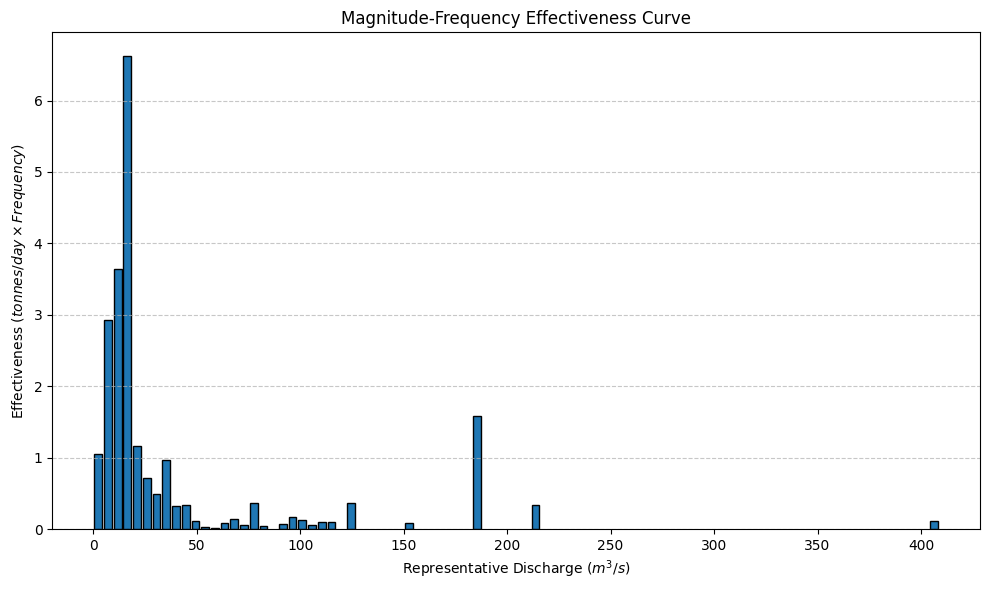

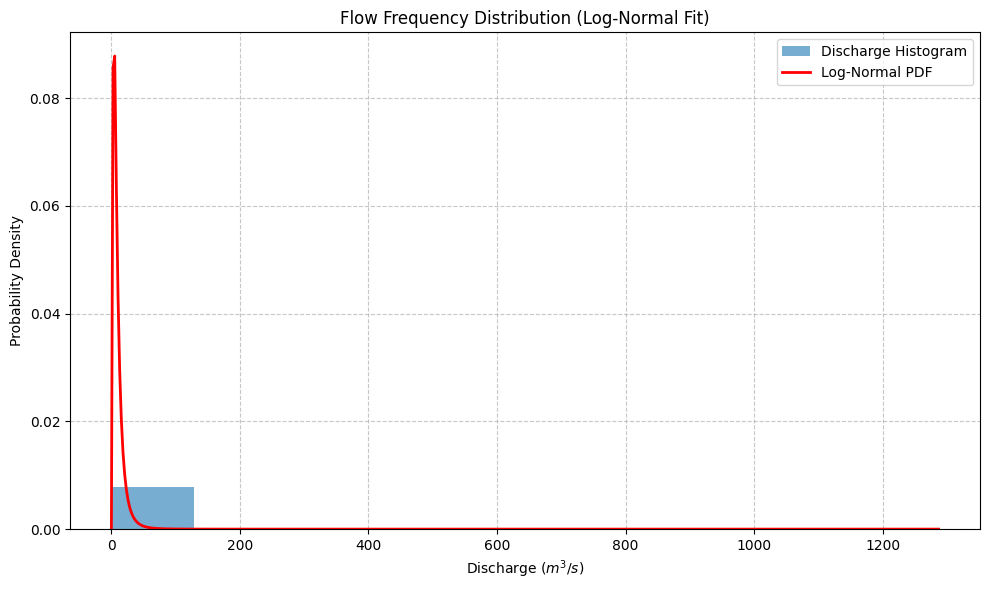

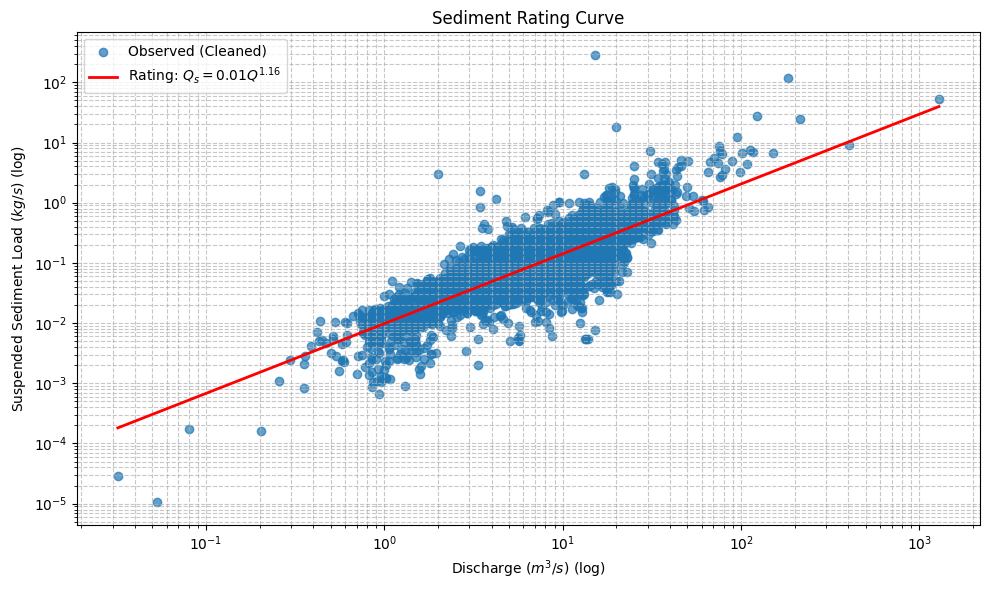

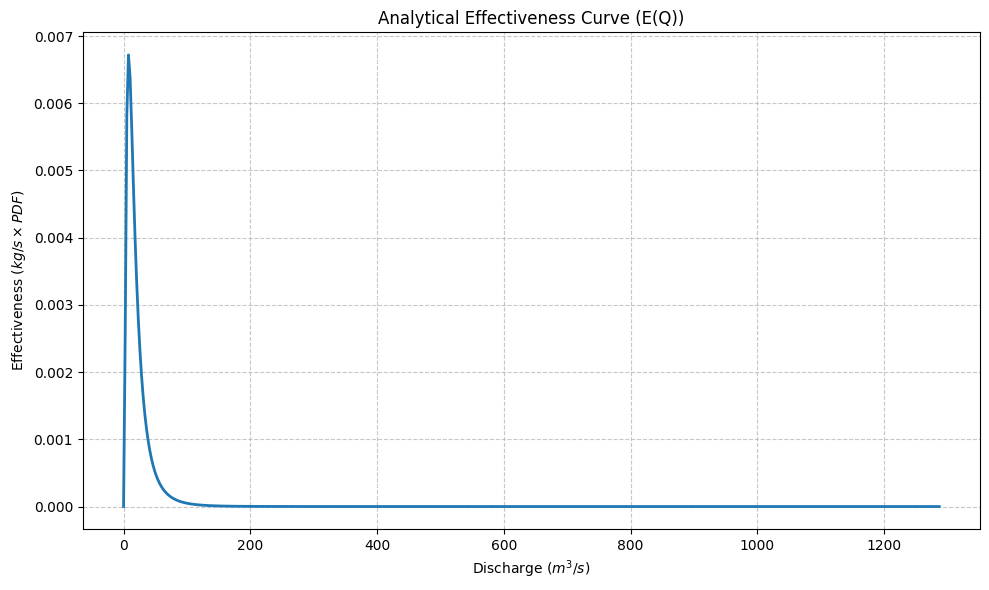

In [39]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Ambreplayan.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1980-06-07 08:00:00           104.0           0.0                 0.0   
1 1980-06-08 08:00:00           188.0           0.0                 0.0   
2 1980-06-09 08:00:00           112.9           0.0                 0.0   
3 1980-06-27 08:00:00           388.0           0.0                 0.0   
4 1980-06-28 08:00:00           250.0           0.0                 0.0   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0             0.0                           0.0                            0.0  
1             0.0                           0.0                            0.0  
2             0.0                           0.0                            0.0  
3             0.0                           0.0                            0.0  
4             0.0                           0.0                            0.0  

Comparison of user's Se

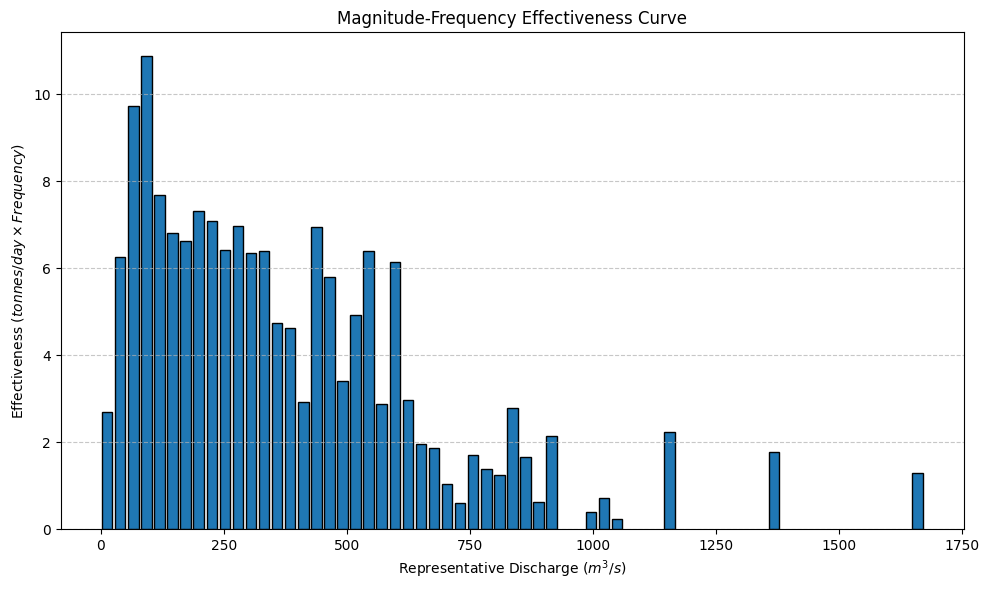

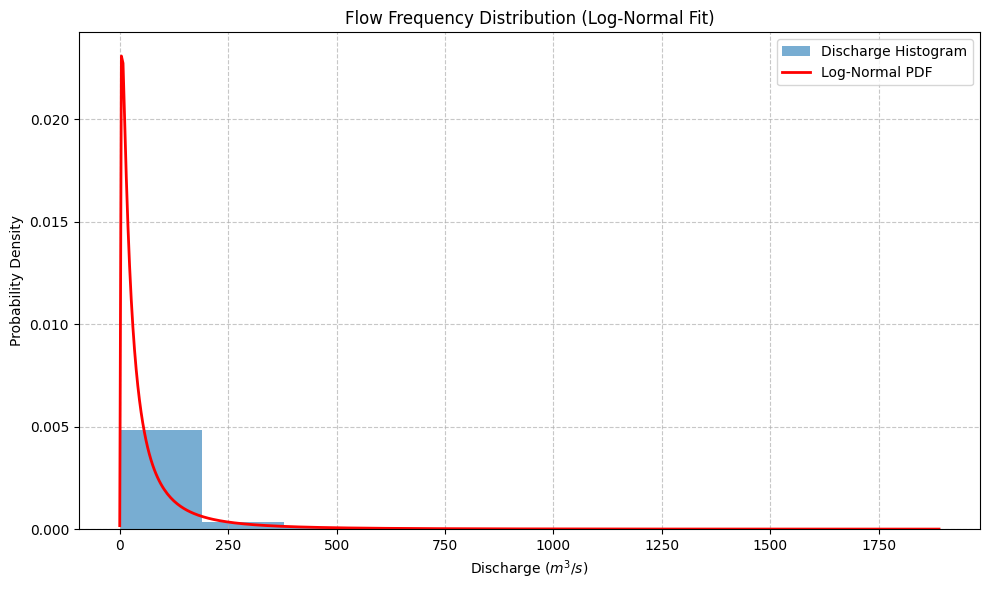

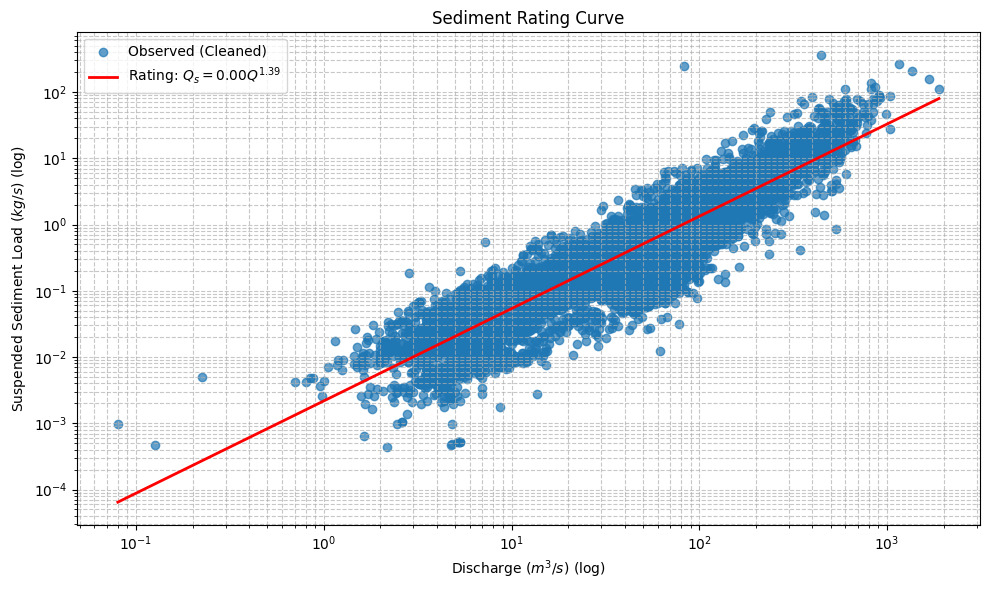

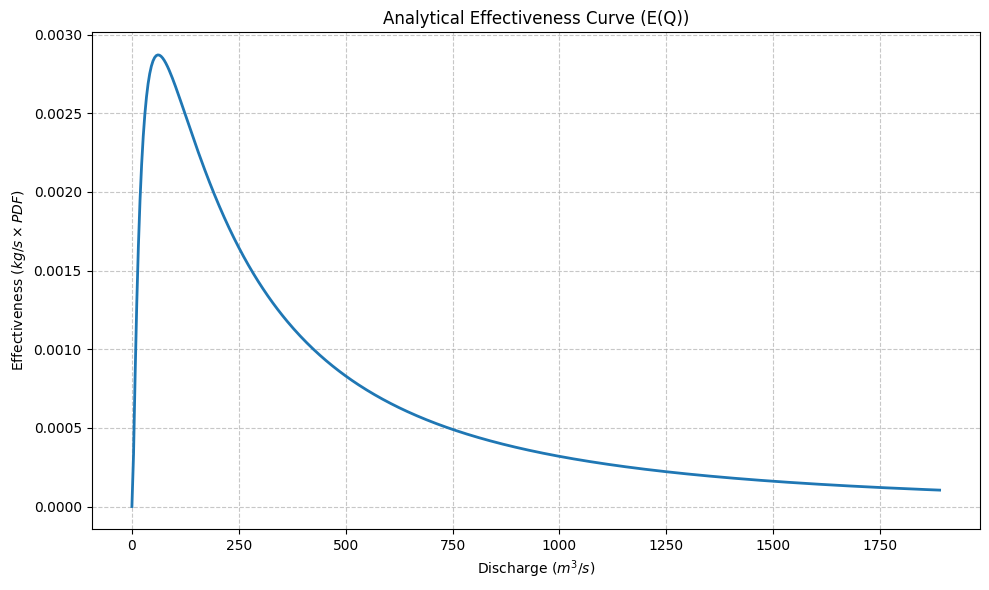

In [40]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Arangali.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1978-12-05 08:00:00            14.7           0.0                 0.0   
1 1978-12-06 08:00:00            13.0           0.0                 0.0   
2 1978-12-07 08:00:00            12.0           0.0                 0.0   
3 1978-12-08 08:00:00            11.5           0.0                 0.0   
4 1978-12-09 08:00:00            11.1           0.0                 0.0   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0             0.0                           0.0                            0.0  
1             0.0                           0.0                            0.0  
2             0.0                           0.0                            0.0  
3             0.0                           0.0                            0.0  
4             0.0                           0.0                            0.0  

Comparison of user's Se

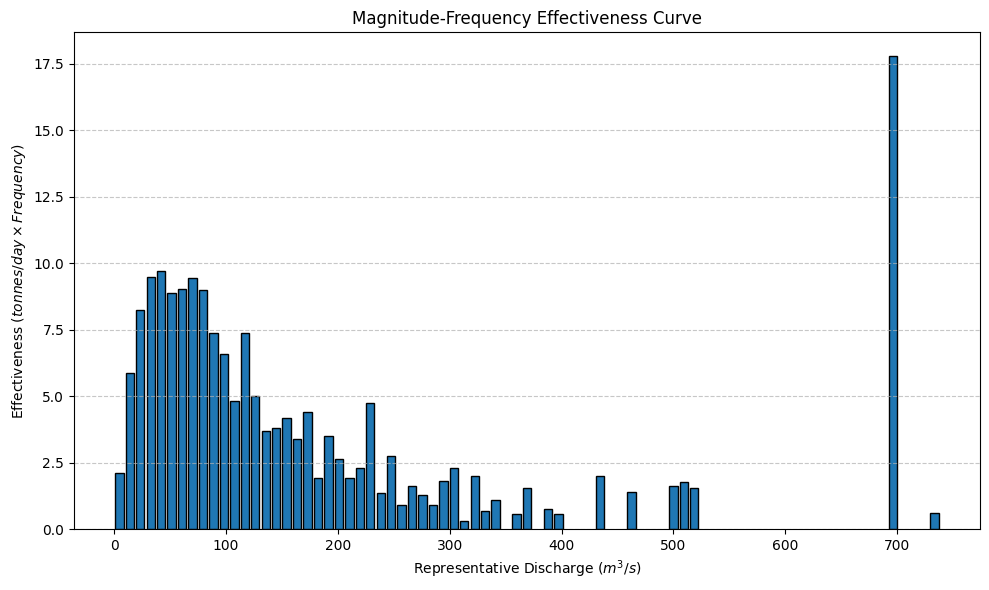

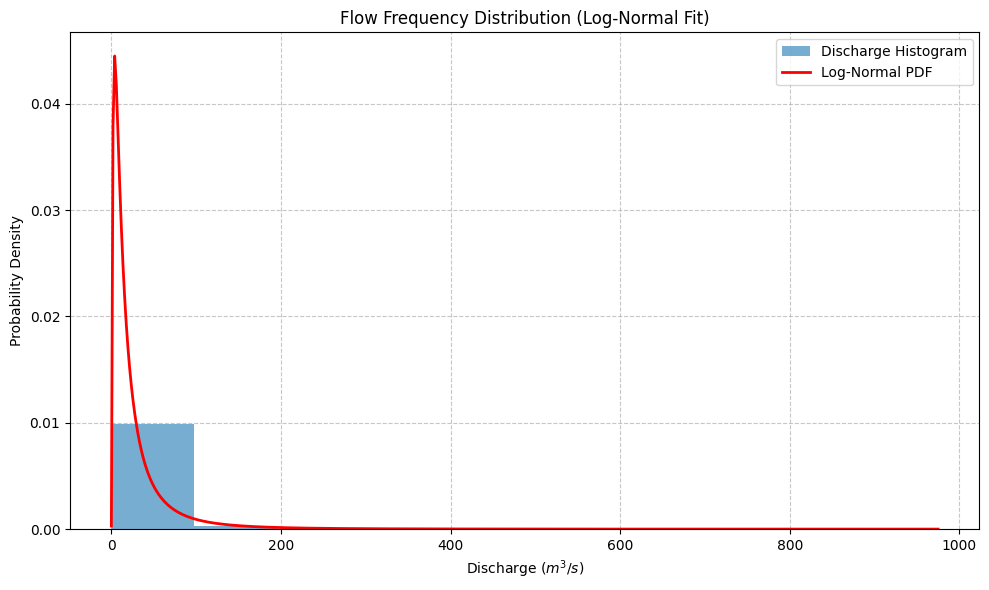

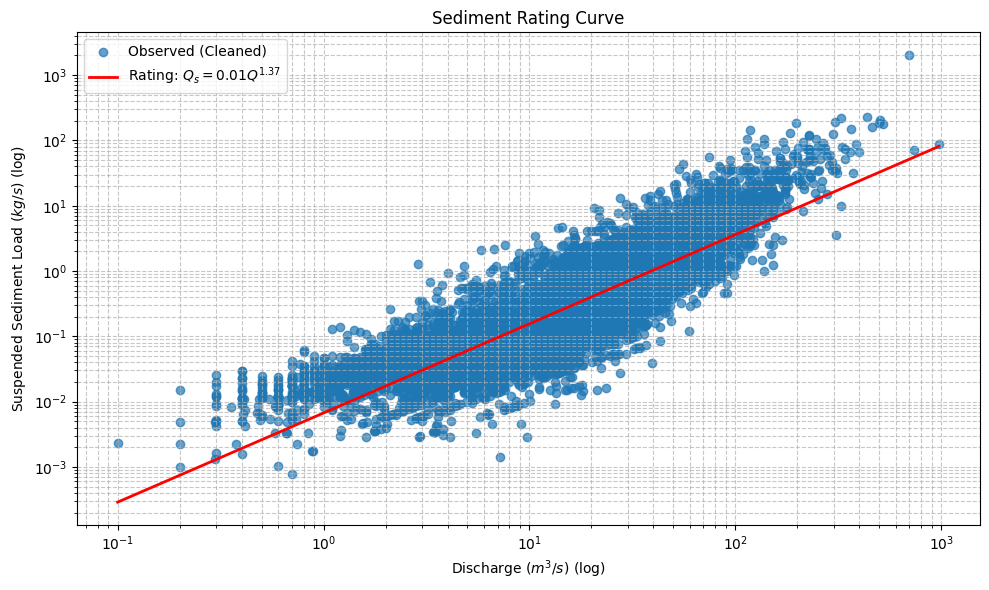

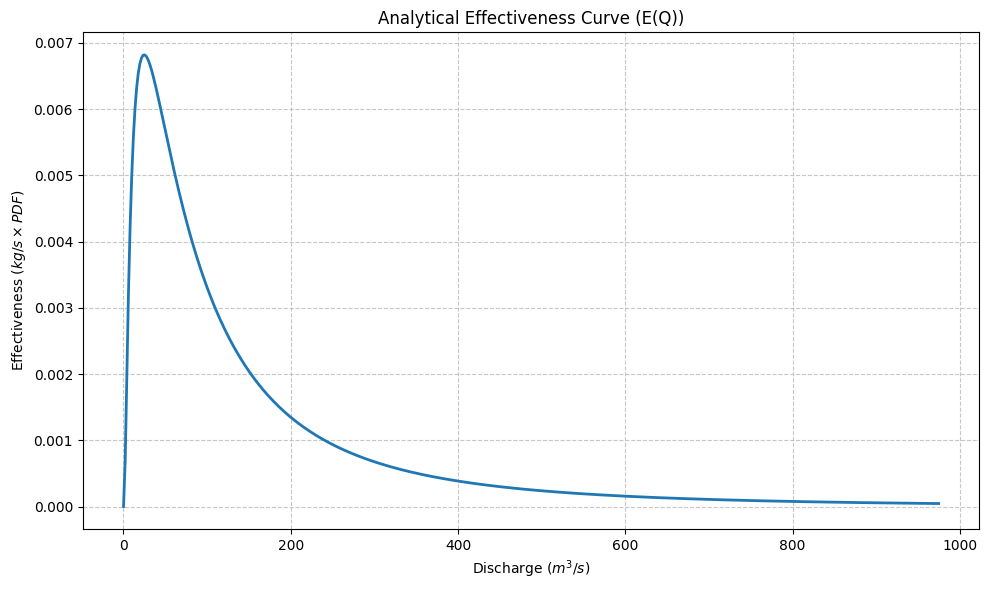

In [41]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Ayilam.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1988-06-11 08:00:00            20.0        0.0510            88.12800   
1 1988-06-12 08:00:00            20.0        0.0510            88.12800   
2 1988-06-19 08:00:00            13.0        0.0140            15.72480   
3 1988-06-26 08:00:00            44.0        0.0304           115.56864   
4 1988-07-03 08:00:00            44.0        0.0298           113.28768   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0510                        1.0200                       88.12800  
1          0.0510                        1.0200                       88.12800  
2          0.0140                        0.1820                       15.72480  
3          0.0304                        1.3376                      115.56864  
4          0.0298                        1.3112                      113.28768  

Comparison of user's Se

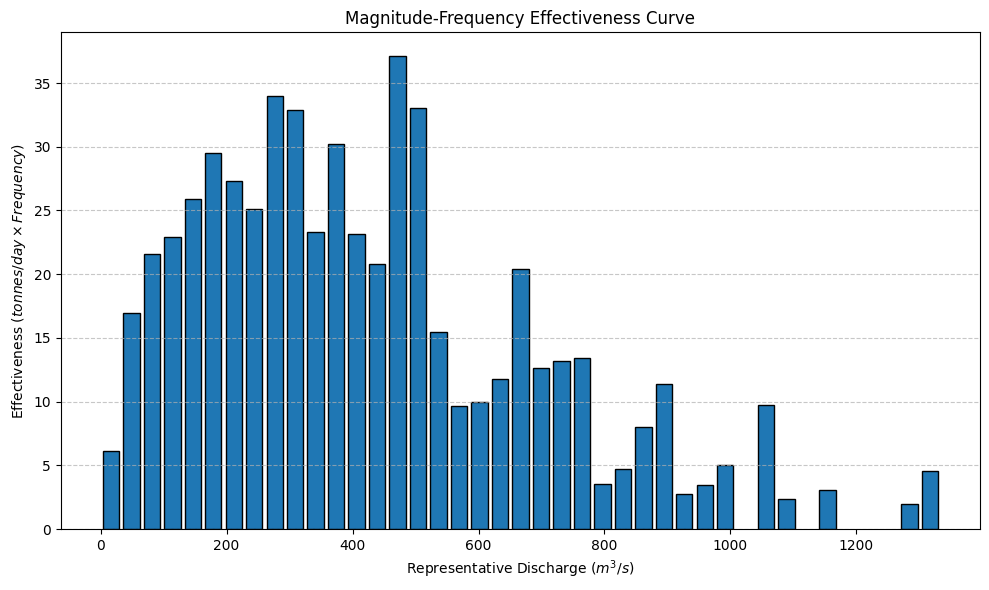

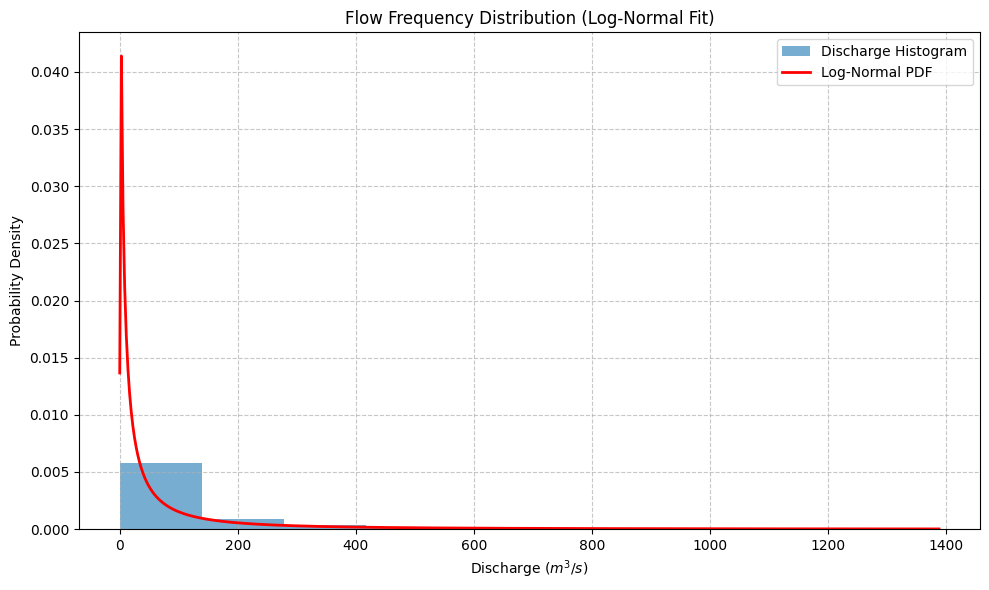

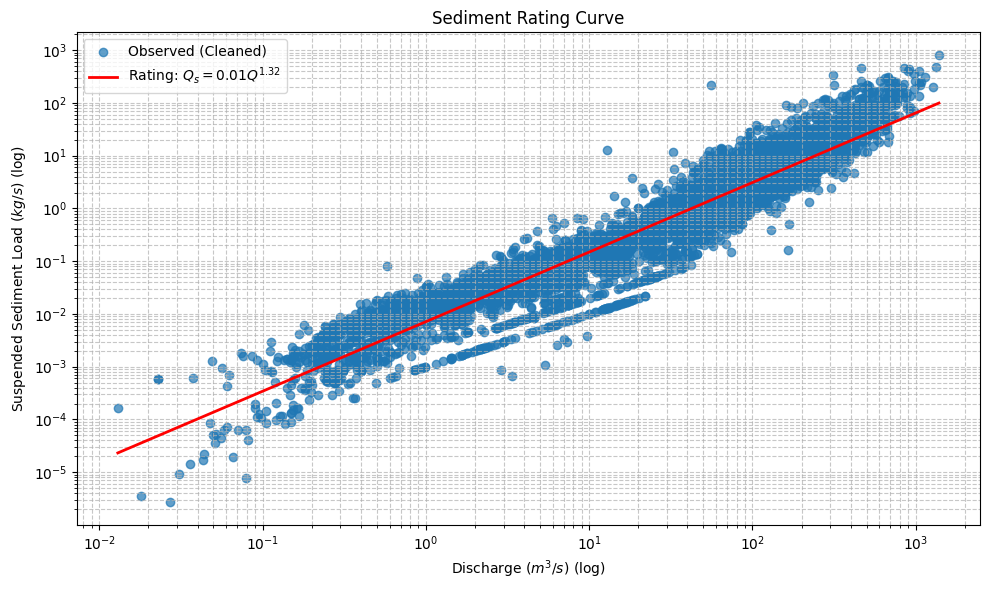

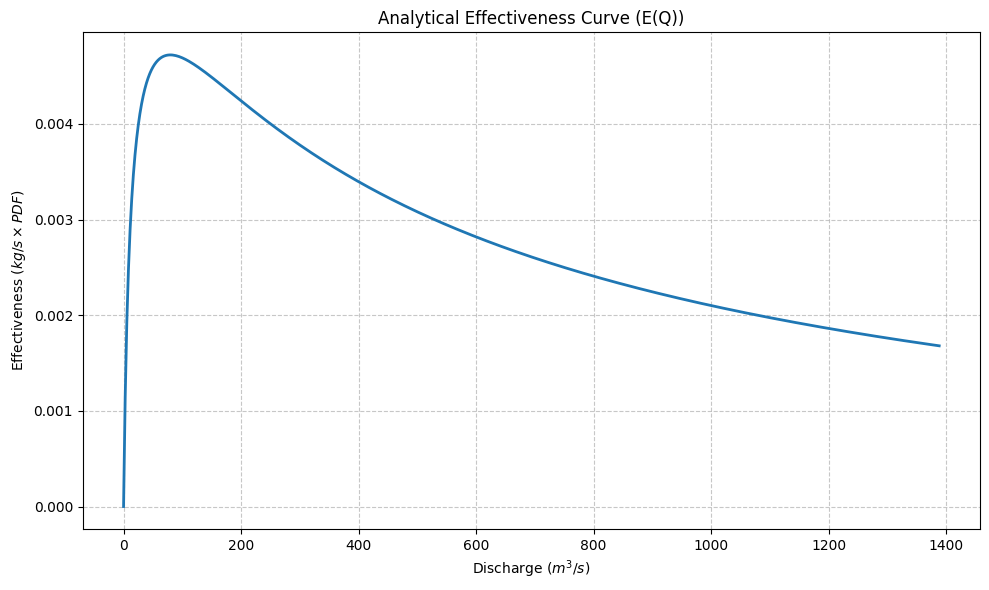

In [42]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Erinjipuzha.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1988-06-05 08:00:00            22.5         0.042             81.6480   
1 1988-06-12 08:00:00            42.7         0.025             92.2320   
2 1988-06-19 08:00:00            20.0         0.013             22.4640   
3 1988-06-24 08:00:00            34.5         0.035            104.3280   
4 1988-06-26 08:00:00            35.5         0.023             70.5456   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0           0.042                        0.9450                        81.6480  
1           0.025                        1.0675                        92.2320  
2           0.013                        0.2600                        22.4640  
3           0.035                        1.2075                       104.3280  
4           0.023                        0.8165                        70.5456  

Comparison of user's Se

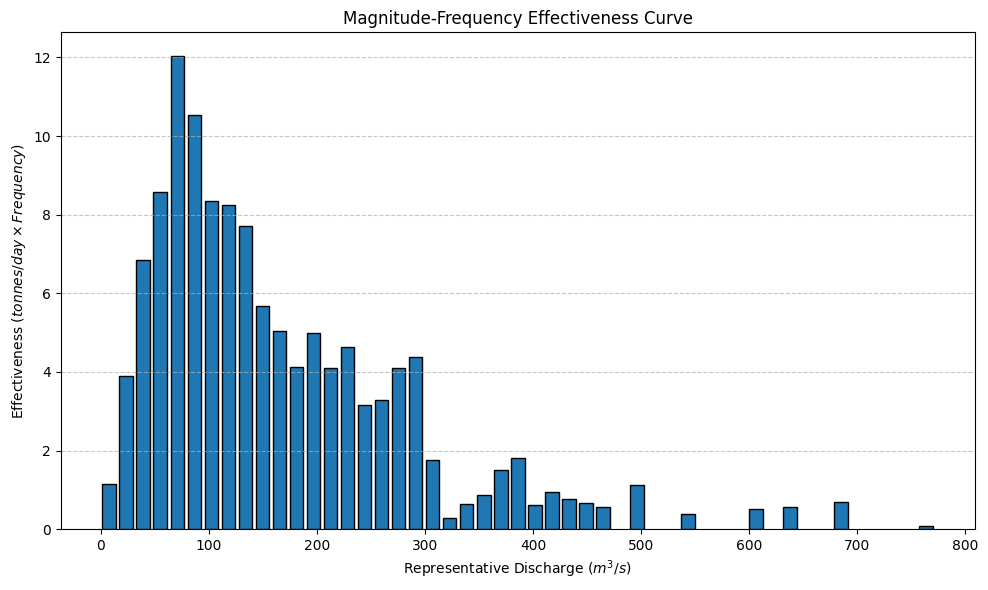

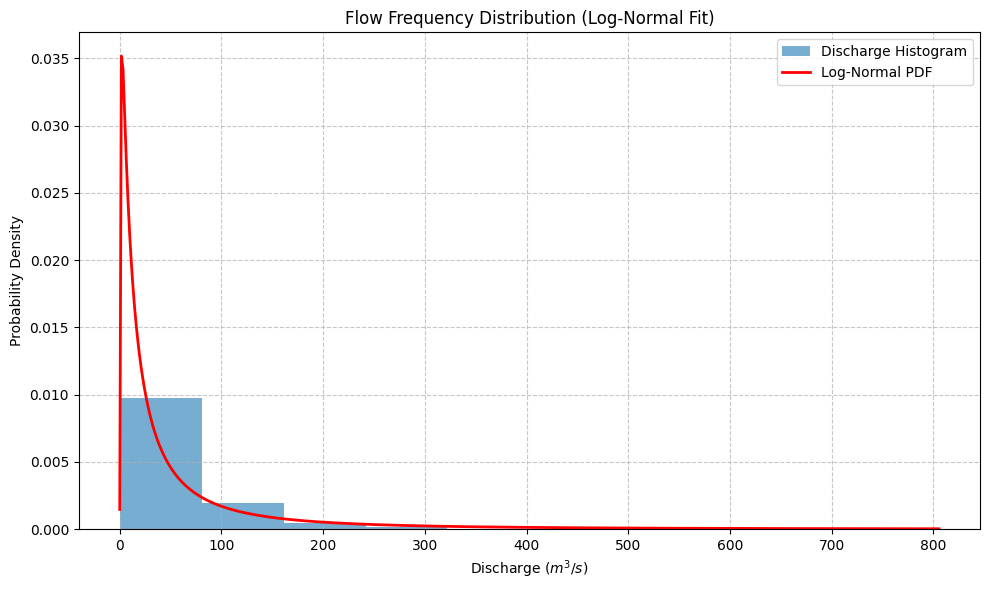

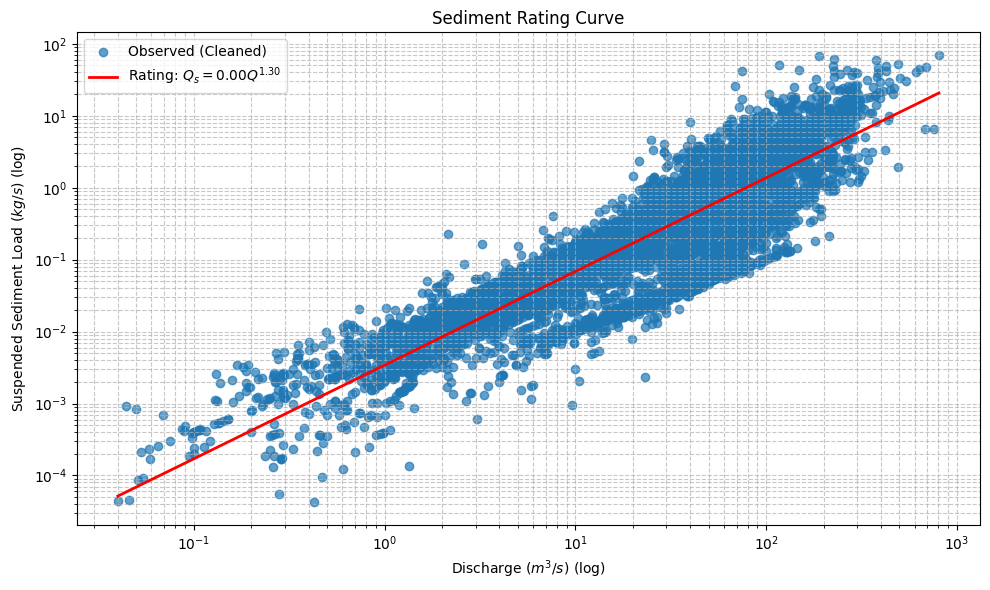

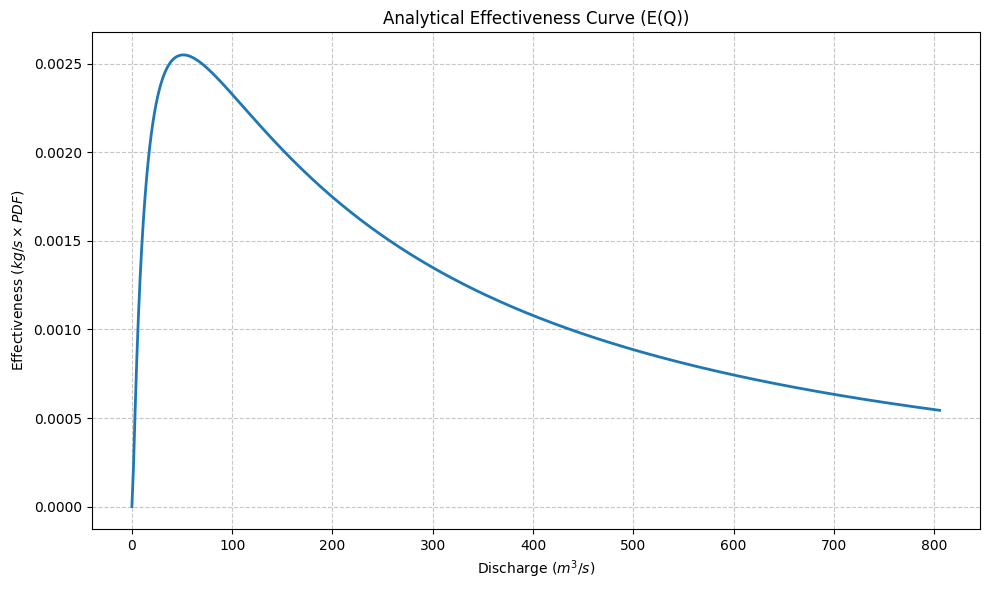

In [43]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Kalampur.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1986-06-08 08:00:00            14.0       0.01900           22.982400   
1 1986-06-09 08:00:00             8.0       0.00720            4.976640   
2 1986-06-15 08:00:00           152.0       0.02213          290.628864   
3 1986-06-30 08:00:00           151.5       0.01280          167.546880   
4 1986-08-15 08:00:00           118.0       0.01060          108.069120   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0         0.01900                       0.26600                      22.982400  
1         0.00720                       0.05760                       4.976640  
2         0.02213                       3.36376                     290.628864  
3         0.01280                       1.93920                     167.546880  
4         0.01060                       1.25080                     108.069120  

Comparison of user's Se

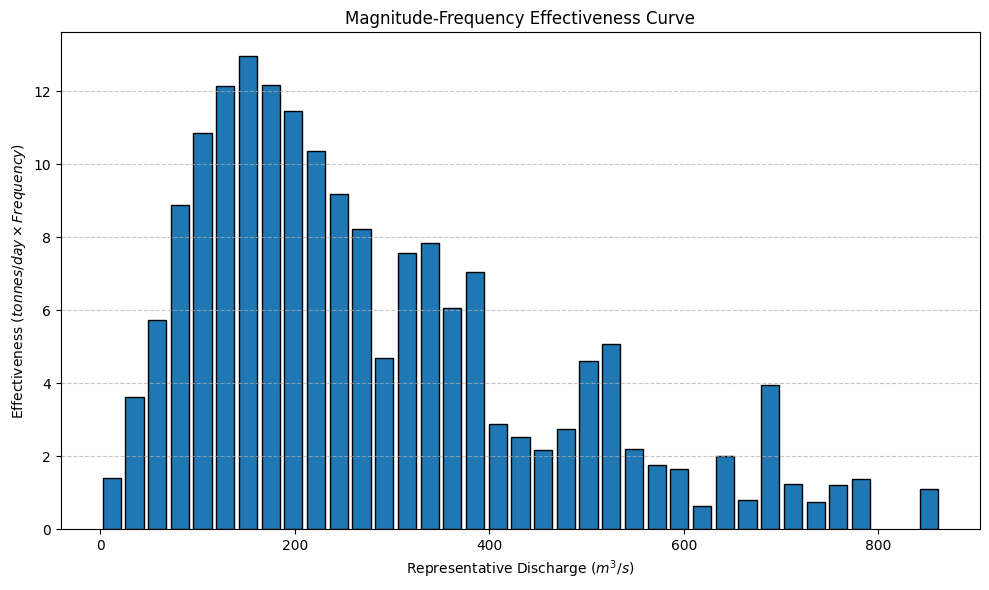

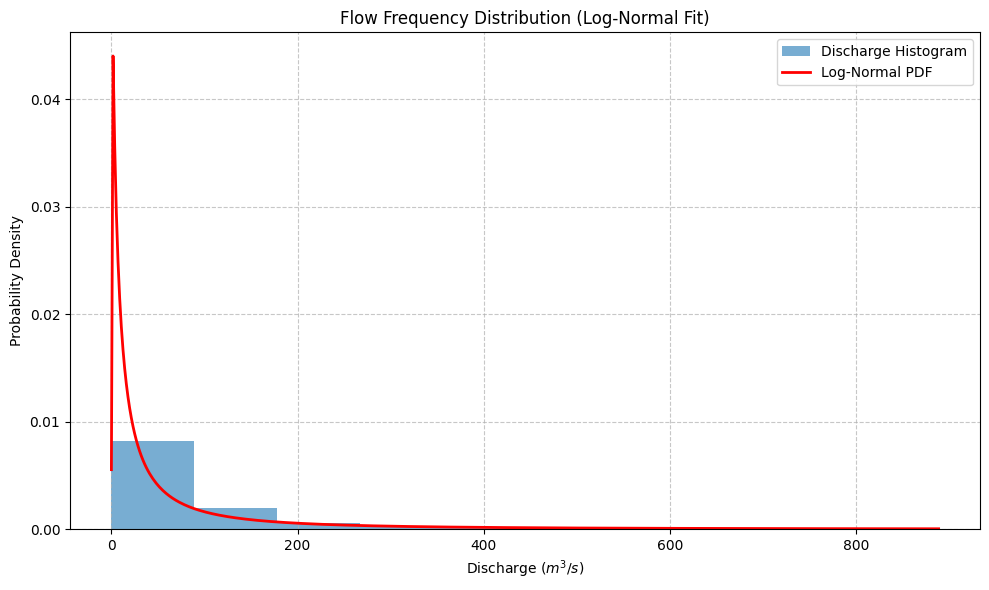

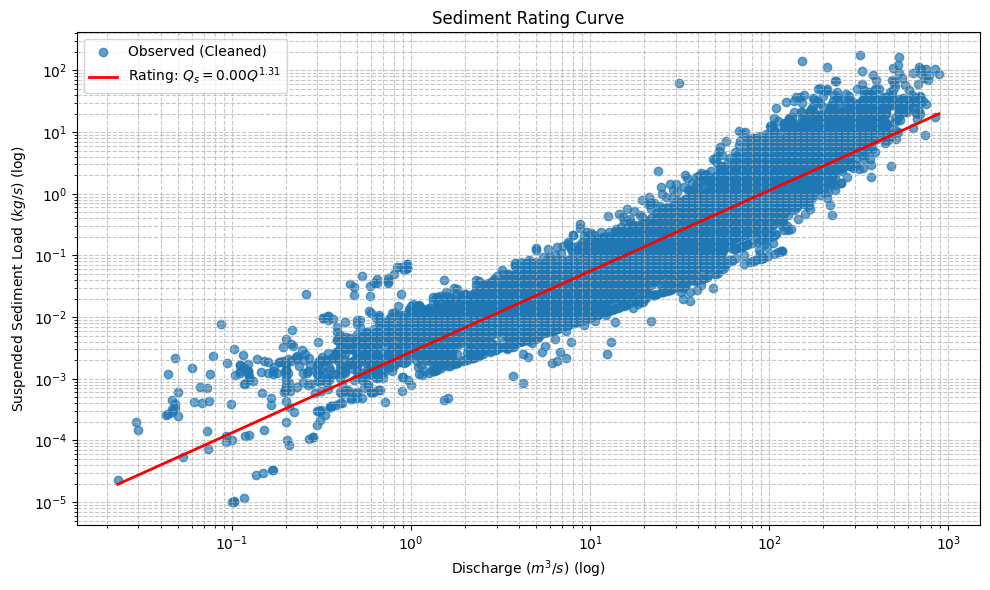

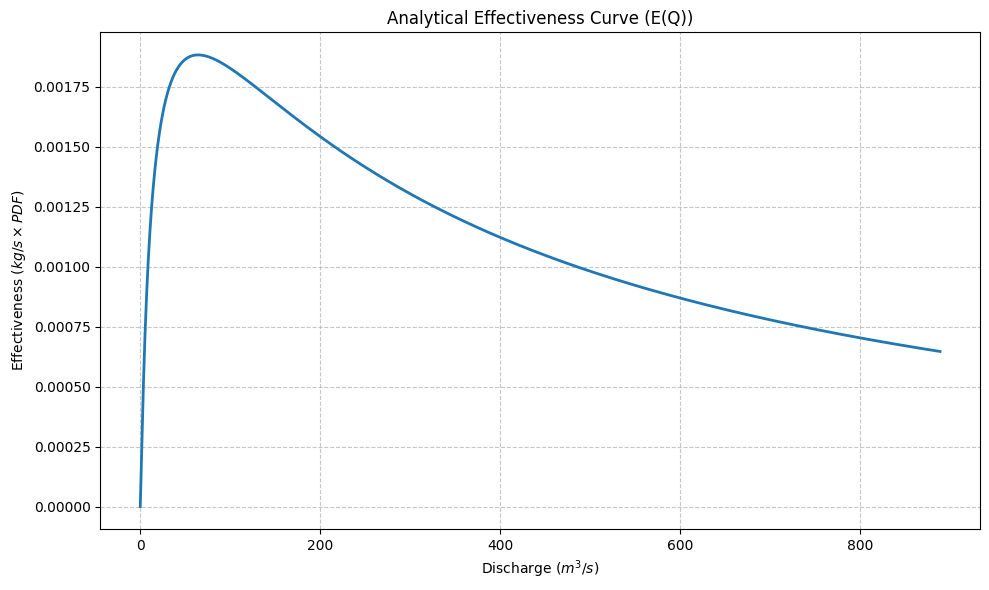

In [44]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Kallooppara.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1989-06-11 08:00:00            33.5        0.0203            58.75632   
1 1989-06-20 08:00:00            27.5        0.0164            38.96640   
2 1989-06-25 08:00:00            65.0        0.0390           219.02400   
3 1989-07-07 08:00:00            30.0        0.0124            32.14080   
4 1989-07-09 08:00:00            45.0        0.0380           147.74400   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0203                       0.68005                       58.75632  
1          0.0164                       0.45100                       38.96640  
2          0.0390                       2.53500                      219.02400  
3          0.0124                       0.37200                       32.14080  
4          0.0380                       1.71000                      147.74400  

Comparison of user's Se

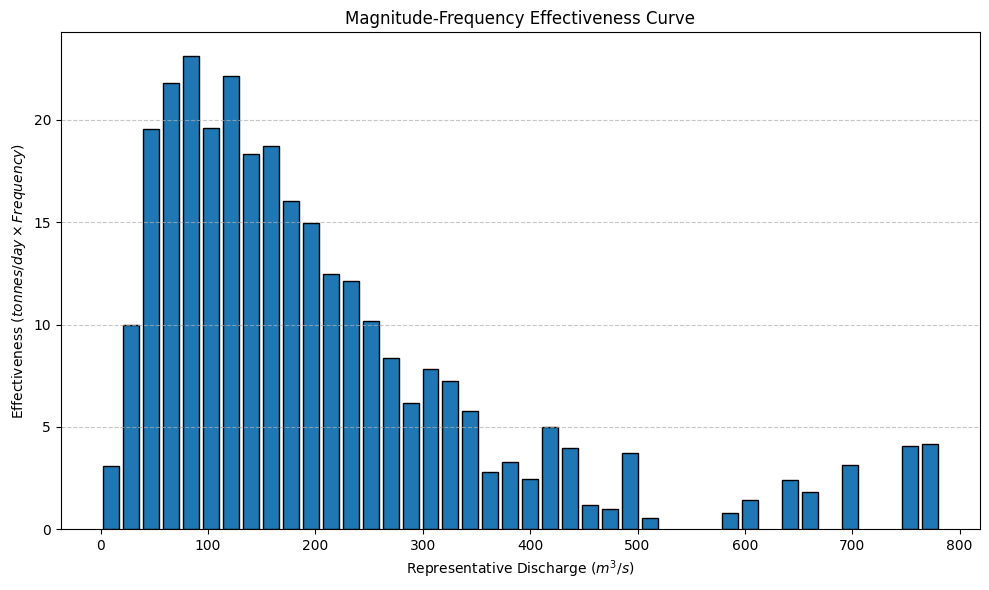

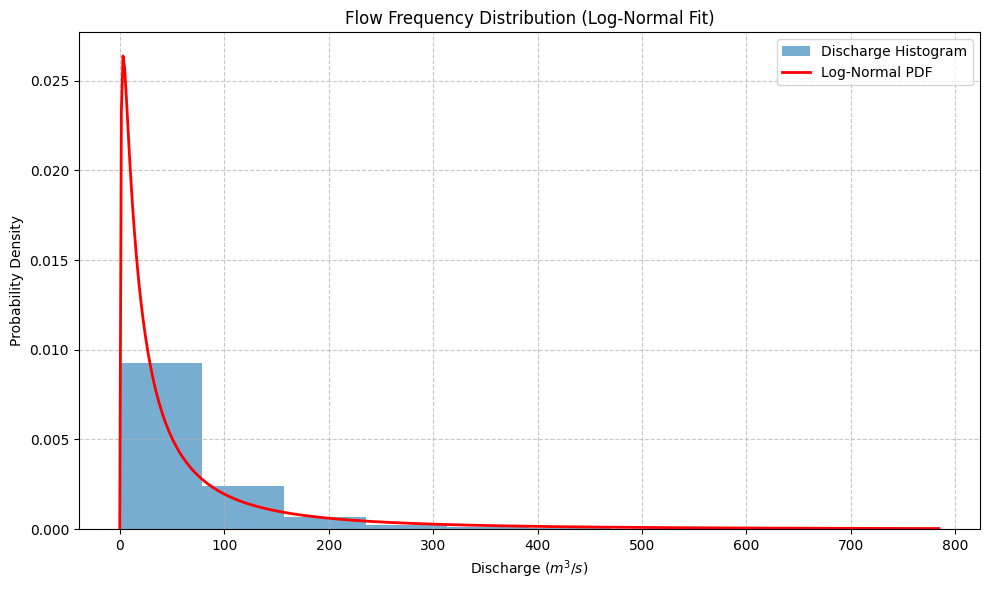

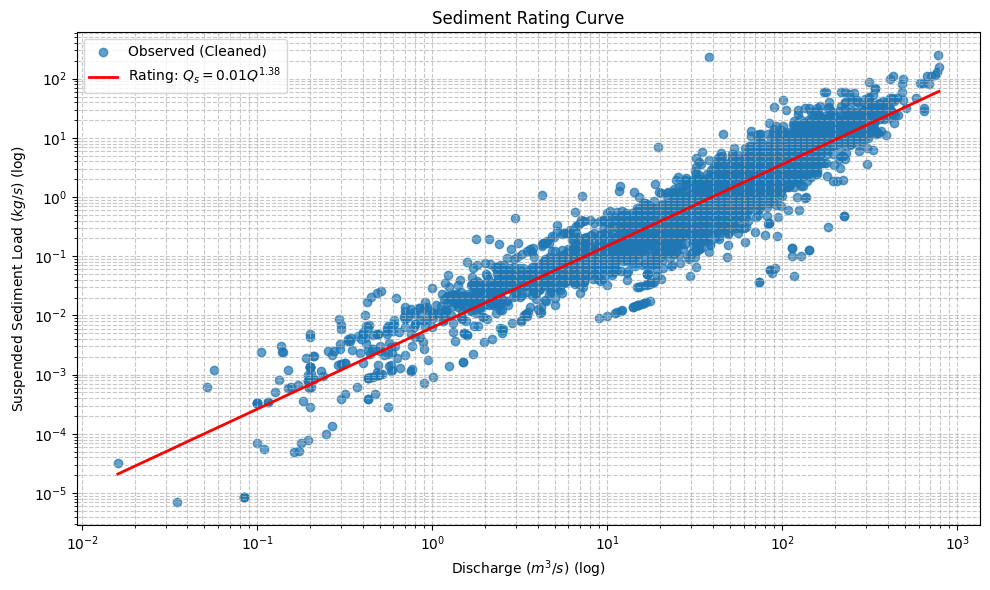

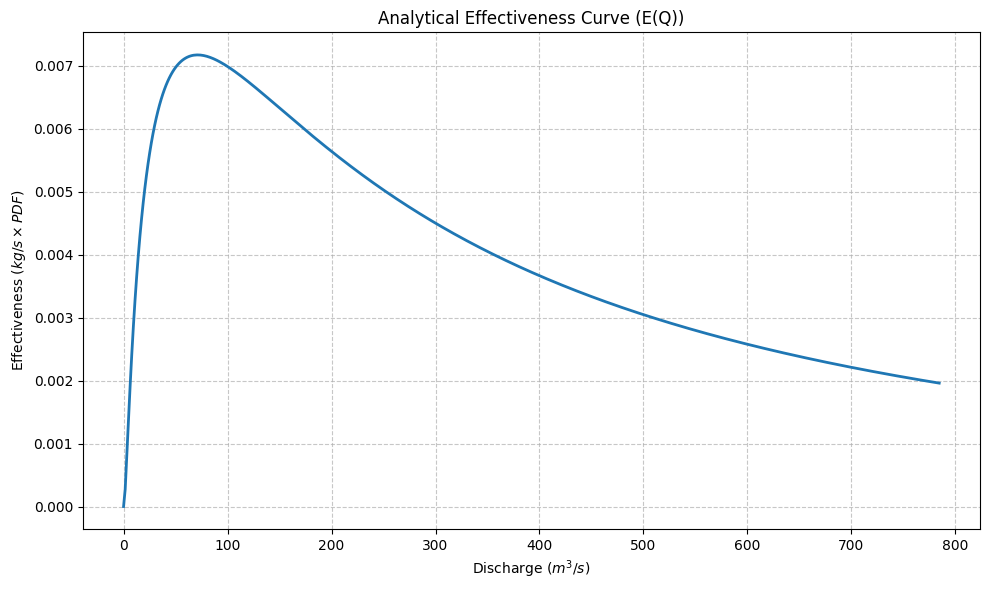

In [46]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Karathodu.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1980-06-05 08:00:00           345.0           0.0                 0.0   
1 1980-06-06 08:00:00           275.0           0.0                 0.0   
2 1980-06-07 08:00:00           335.0           0.0                 0.0   
3 1980-06-08 08:00:00           605.0           0.0                 0.0   
4 1980-06-09 08:00:00           590.0           0.0                 0.0   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0             0.0                           0.0                            0.0  
1             0.0                           0.0                            0.0  
2             0.0                           0.0                            0.0  
3             0.0                           0.0                            0.0  
4             0.0                           0.0                            0.0  

Comparison of user's Se

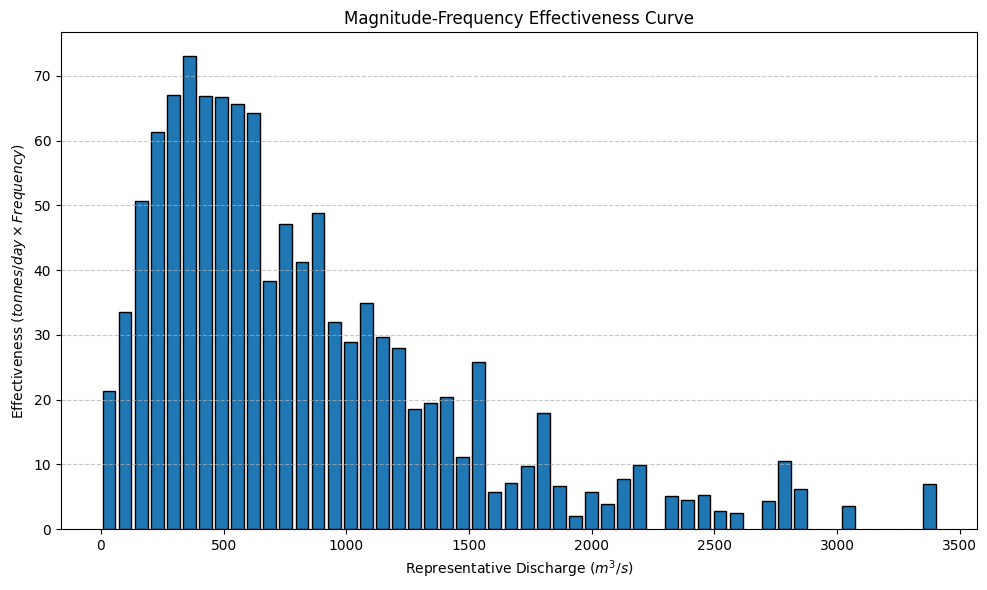

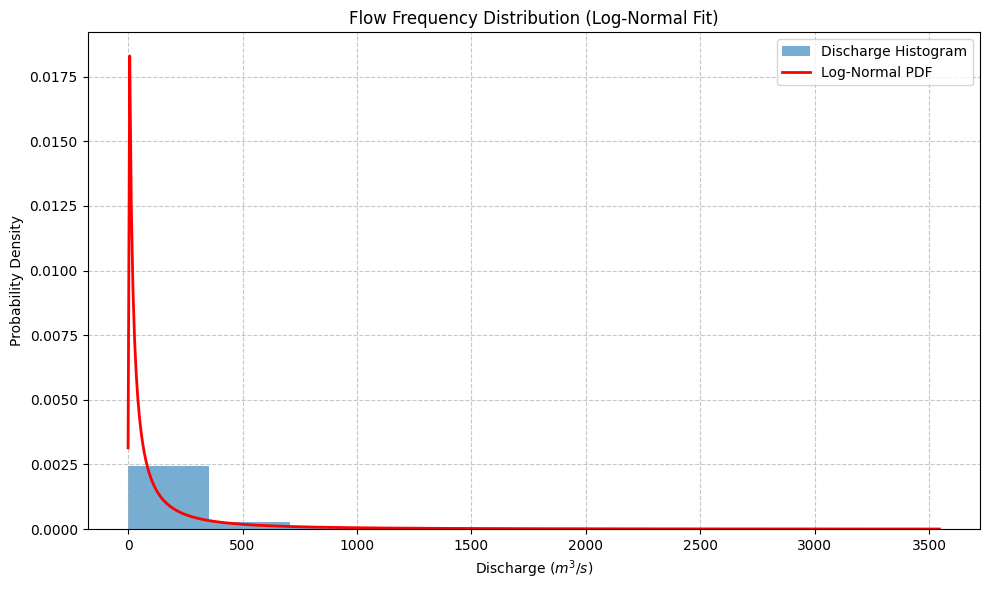

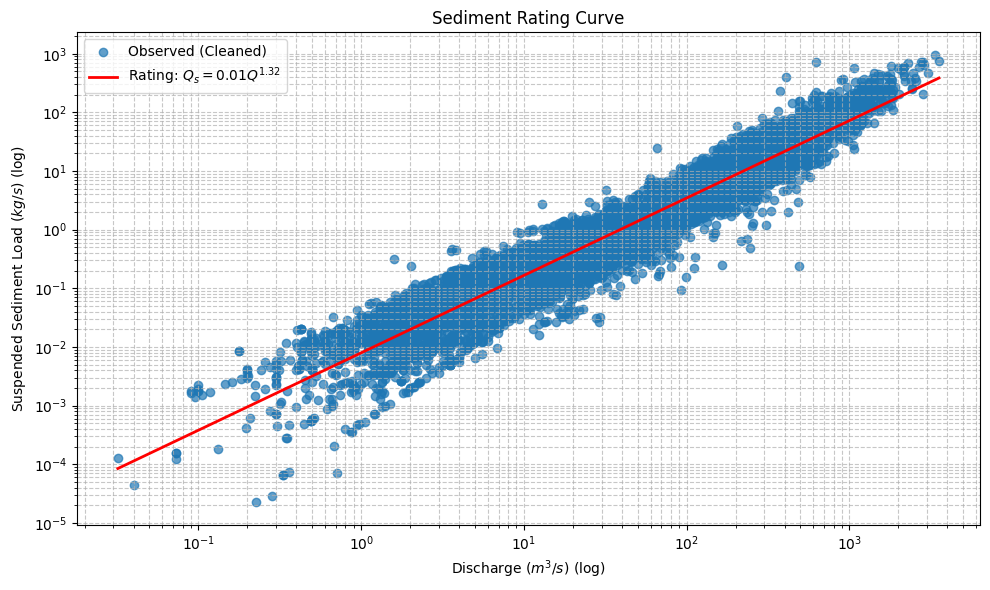

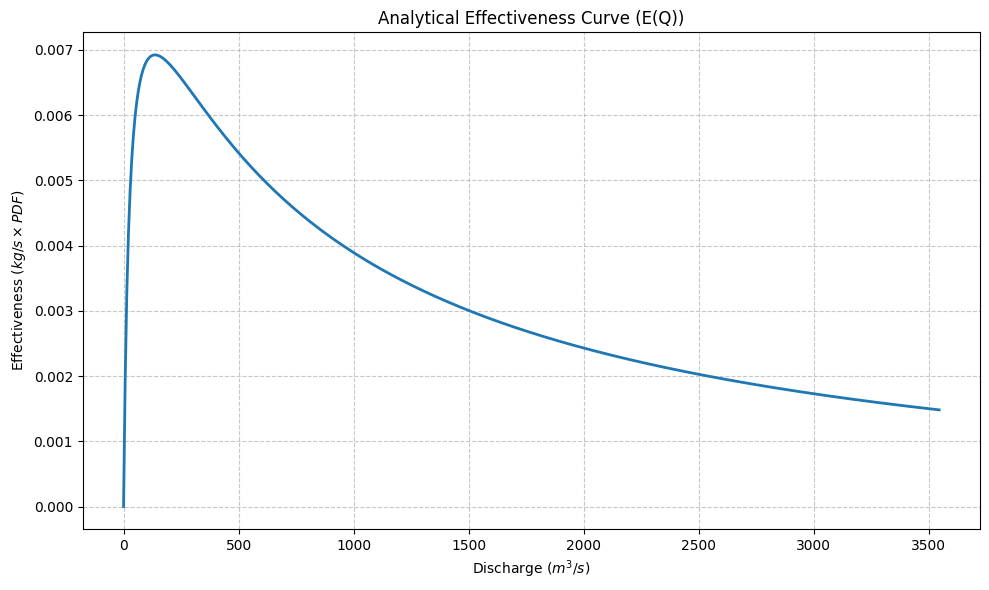

In [45]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Kumbidi.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1979-12-06 08:00:00            63.8        0.0272          149.935104   
1 1979-12-07 08:00:00            62.5        0.0269          145.260000   
2 1979-12-08 08:00:00            56.5        0.0266          129.850560   
3 1979-12-09 08:00:00            52.8        0.0274          124.996608   
4 1979-12-11 08:00:00            40.6        0.0091           31.921344   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0272                       1.73536                     149.935104  
1          0.0269                       1.68125                     145.260000  
2          0.0266                       1.50290                     129.850560  
3          0.0274                       1.44672                     124.996608  
4          0.0091                       0.36946                      31.921344  

Comparison of user's Se

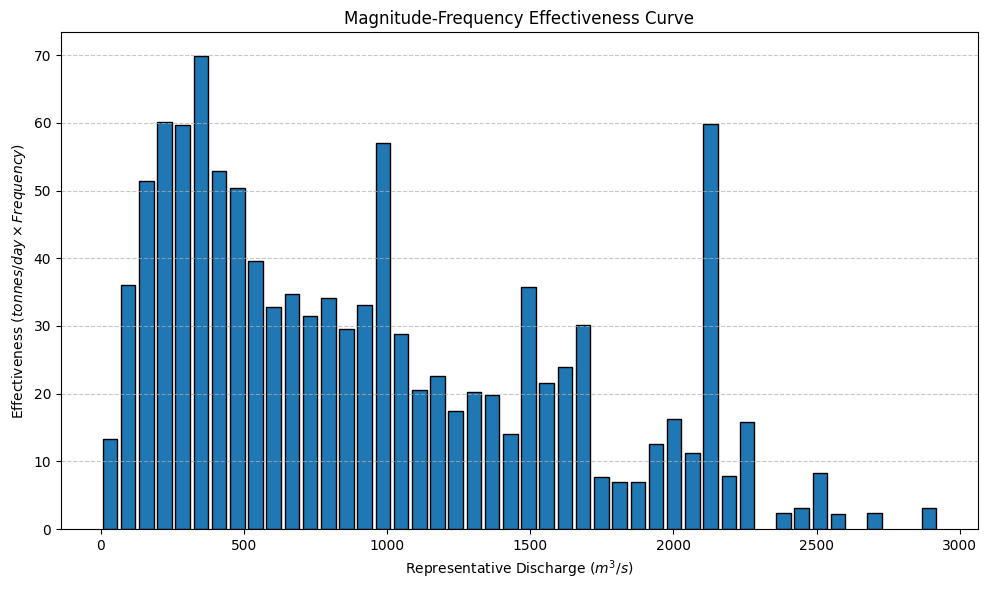

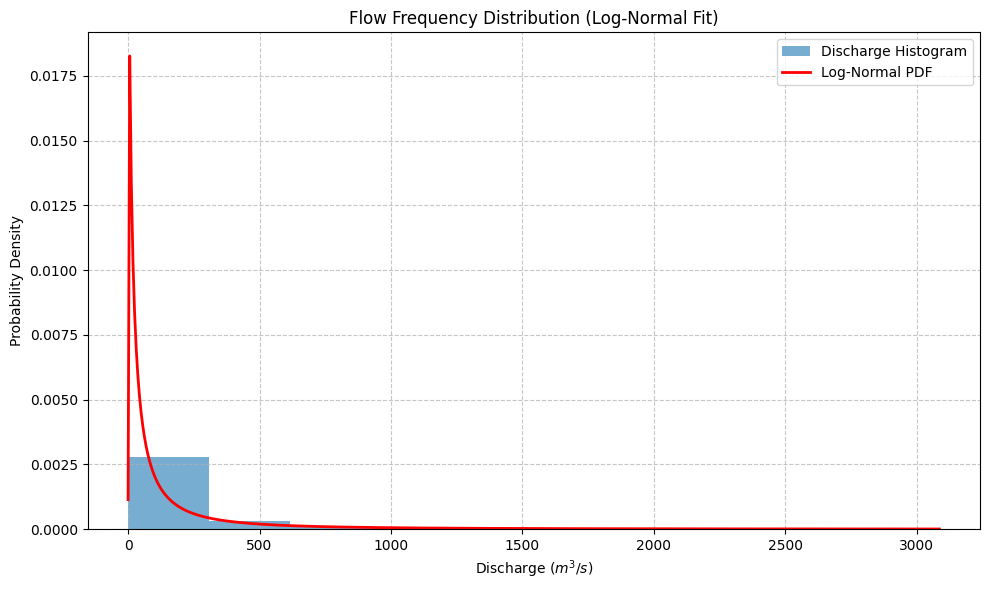

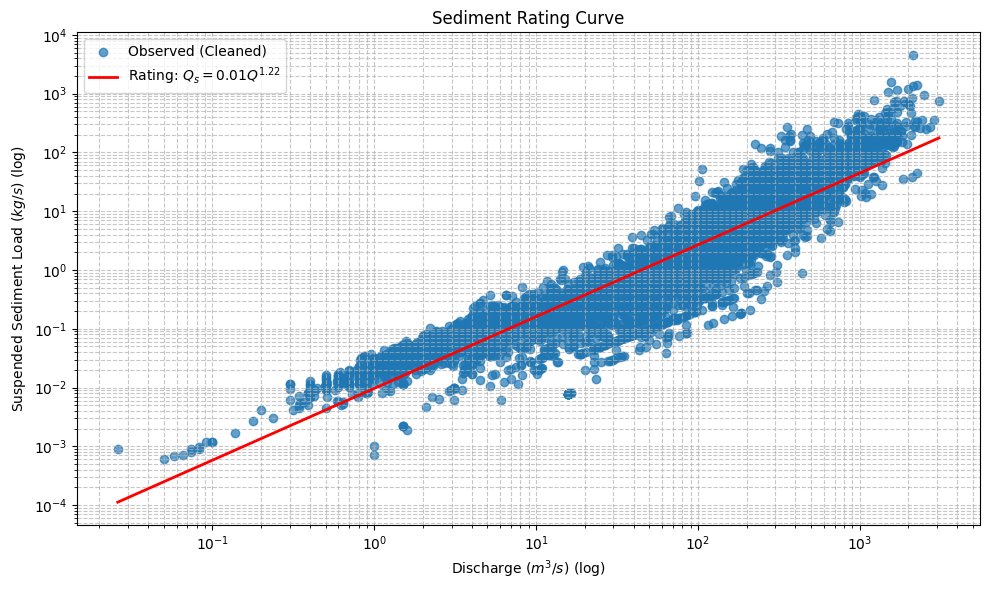

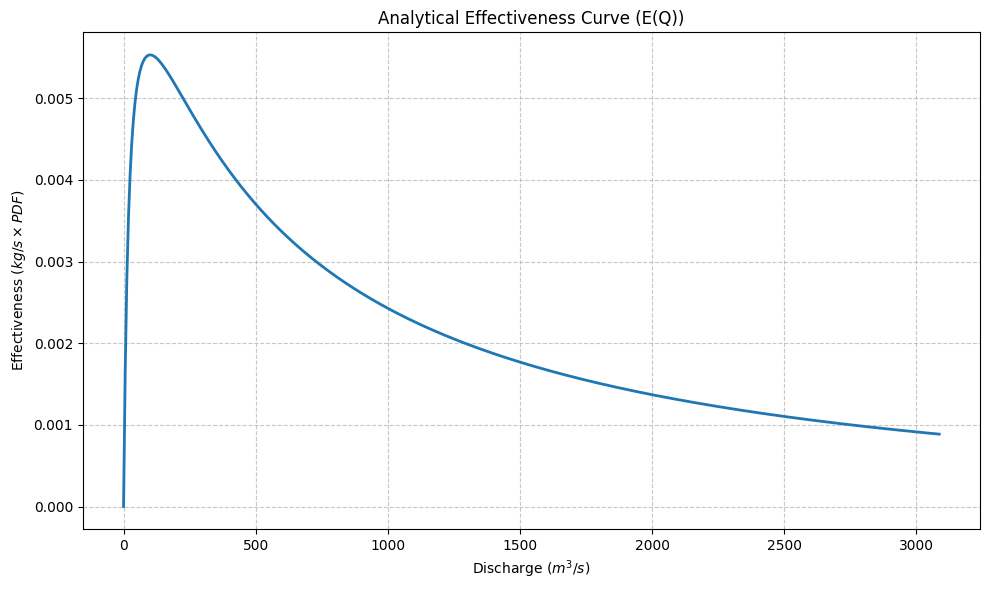

In [47]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Kuniyil.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1986-06-08 08:00:00            33.0        0.0000               0.000   
1 1986-06-22 08:00:00            75.0        0.0144              93.312   
2 1986-07-27 08:00:00           175.0        0.0136             205.632   
3 1986-08-15 08:00:00           375.0        0.0264             855.360   
4 1986-08-31 08:00:00            32.5        0.0050              14.040   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0000                        0.0000                          0.000  
1          0.0144                        1.0800                         93.312  
2          0.0136                        2.3800                        205.632  
3          0.0264                        9.9000                        855.360  
4          0.0050                        0.1625                         14.040  

Comparison of user's Se

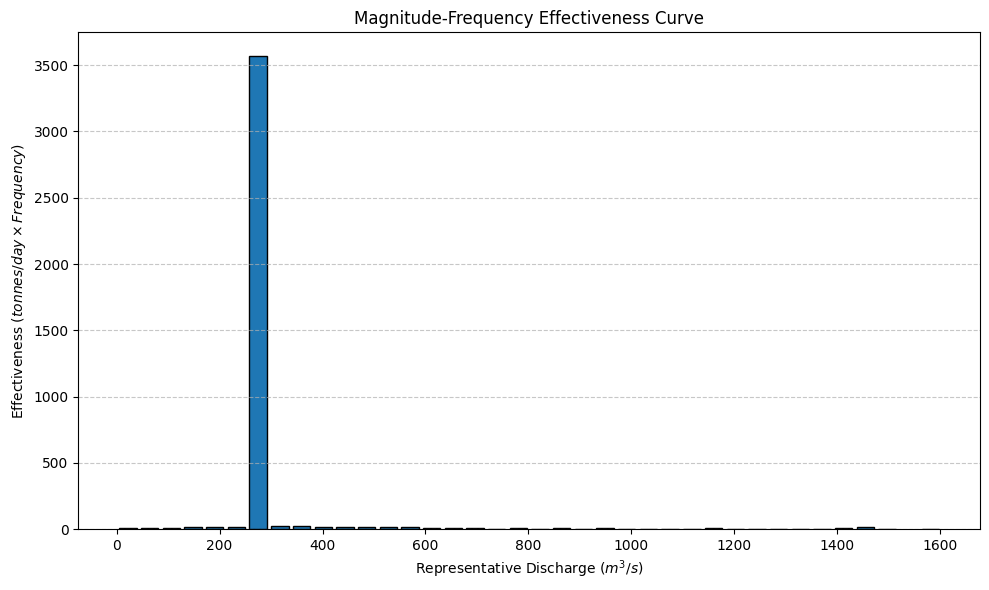

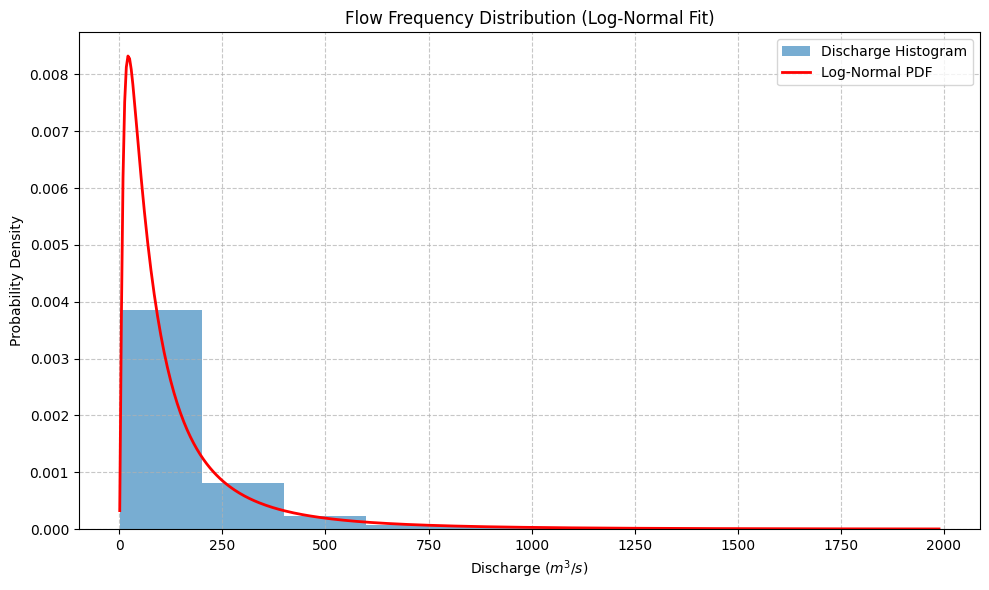

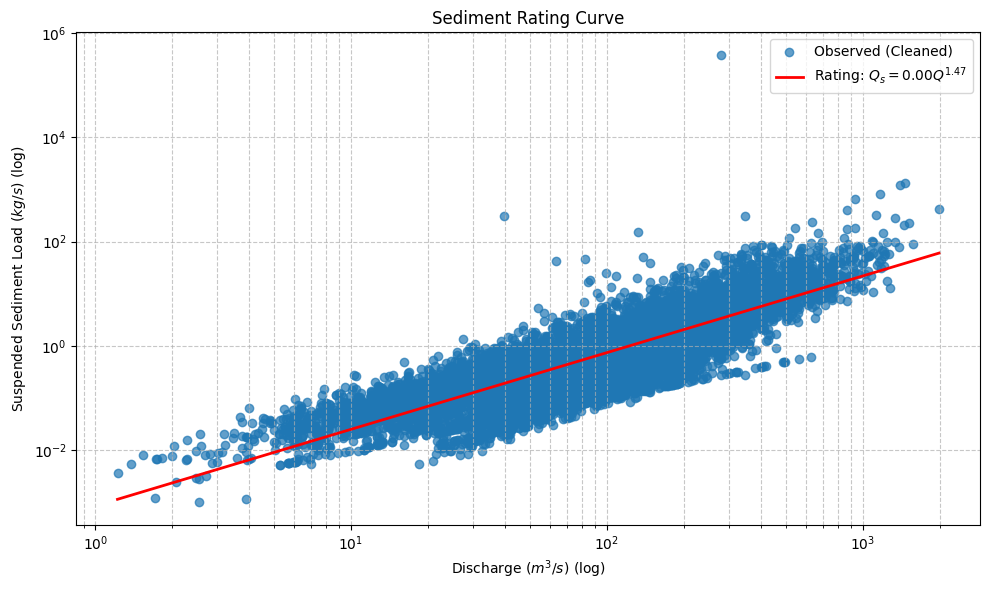

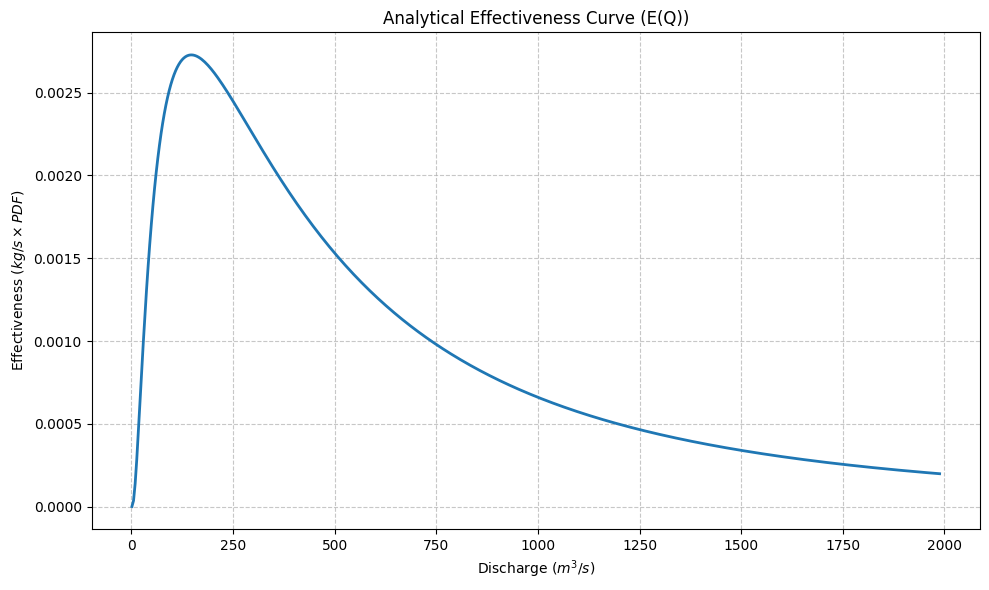

In [48]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Malakkara.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1972-07-04 08:00:00          1260.0      0.034721         3779.901780   
1 1972-07-08 08:00:00          1550.0      0.037196         4981.232074   
2 1972-07-11 08:00:00           915.0      0.029500         2332.152000   
3 1972-07-12 08:00:00           945.0      0.028537         2329.999917   
4 1972-08-06 08:00:00           955.0      0.031026         2559.990743   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0        0.034721                     43.748863                    3779.901780  
1        0.037196                     57.653149                    4981.232074  
2        0.029500                     26.992500                    2332.152000  
3        0.028537                     26.967592                    2329.999917  
4        0.031026                     29.629522                    2559.990743  

Comparison of user's Se

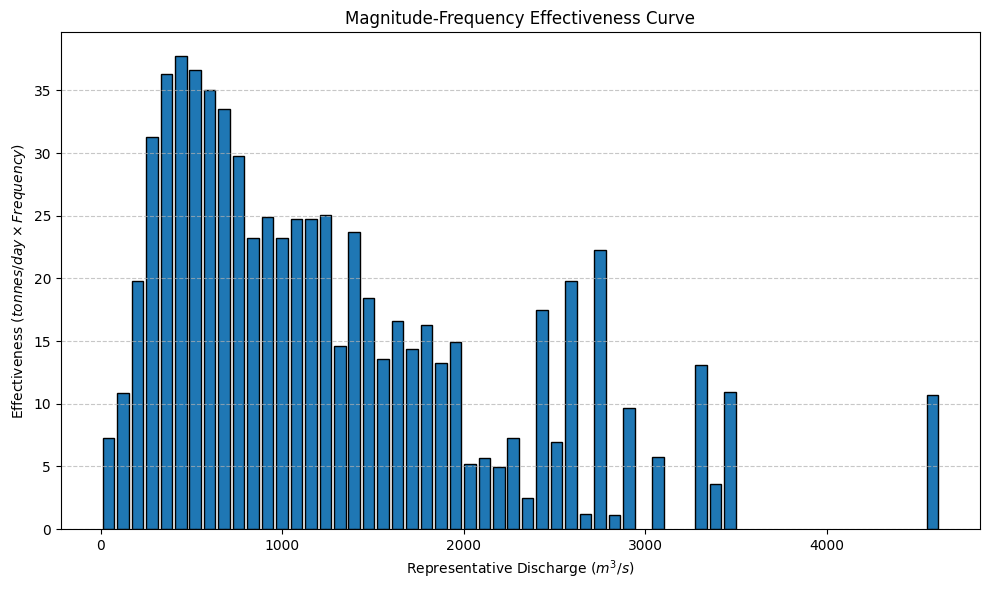

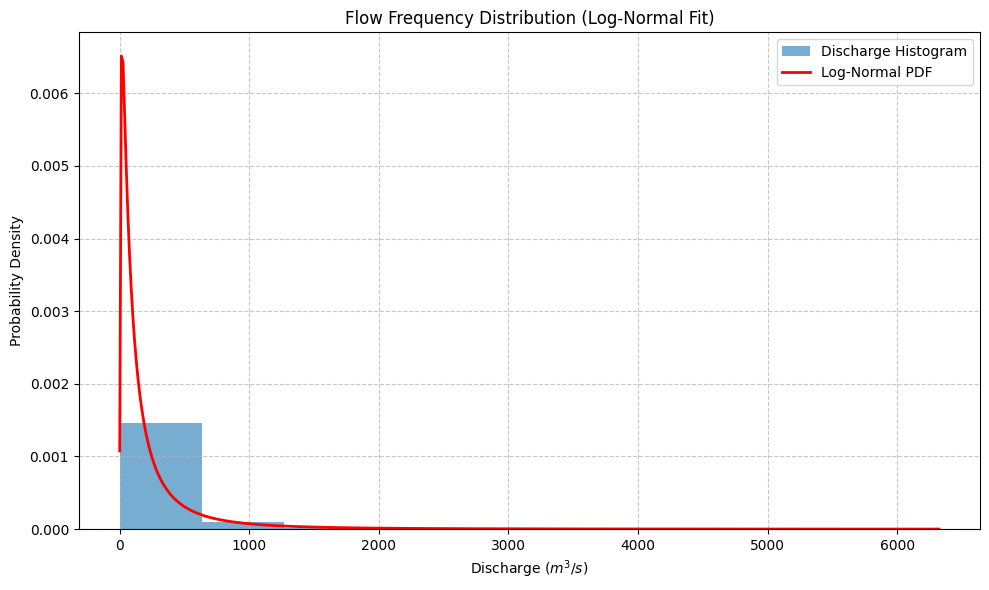

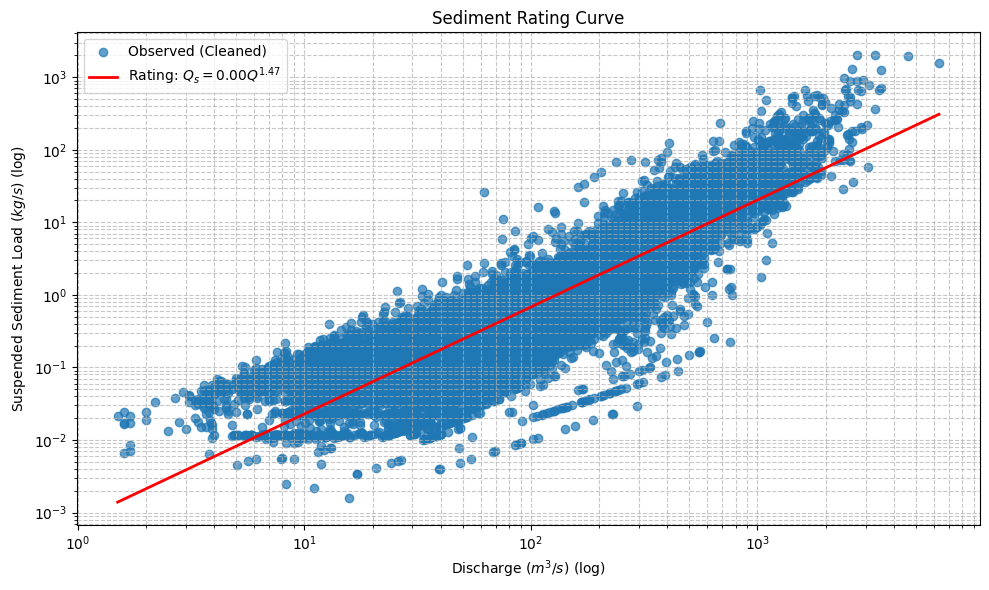

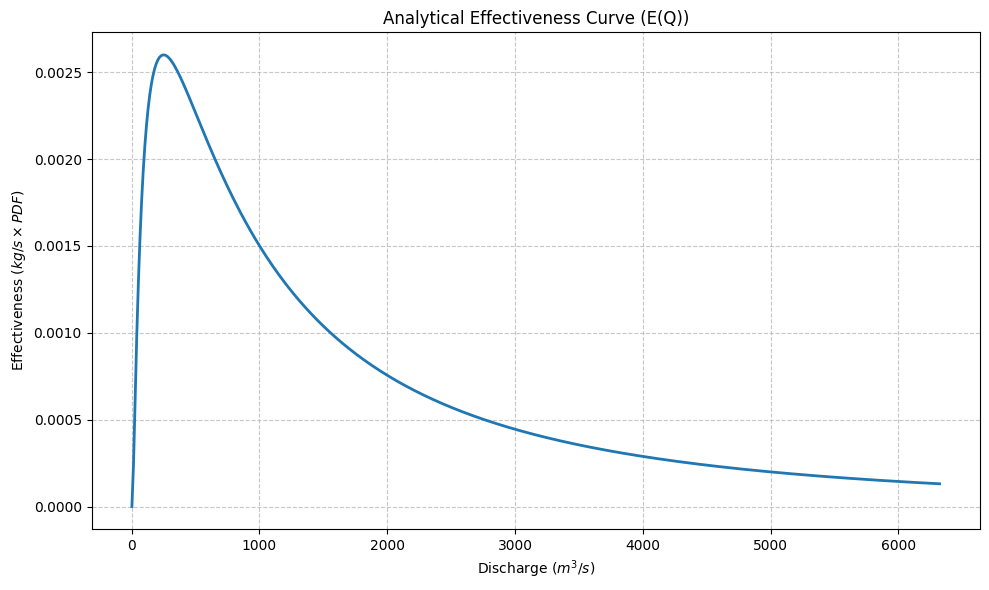

In [49]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Neeleswaram.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1972-06-28 08:00:00          1155.0        0.1895           18910.584   
1 1972-06-29 08:00:00          3320.0        0.4470          128221.056   
2 1972-07-01 08:00:00          3300.0        0.3586          102244.032   
3 1972-07-03 08:00:00          2700.0        0.2549           59463.072   
4 1972-07-04 08:00:00          3065.0        0.3620           95863.392   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.1895                      218.8725                      18910.584  
1          0.4470                     1484.0400                     128221.056  
2          0.3586                     1183.3800                     102244.032  
3          0.2549                      688.2300                      59463.072  
4          0.3620                     1109.5300                      95863.392  

Comparison of user's Se

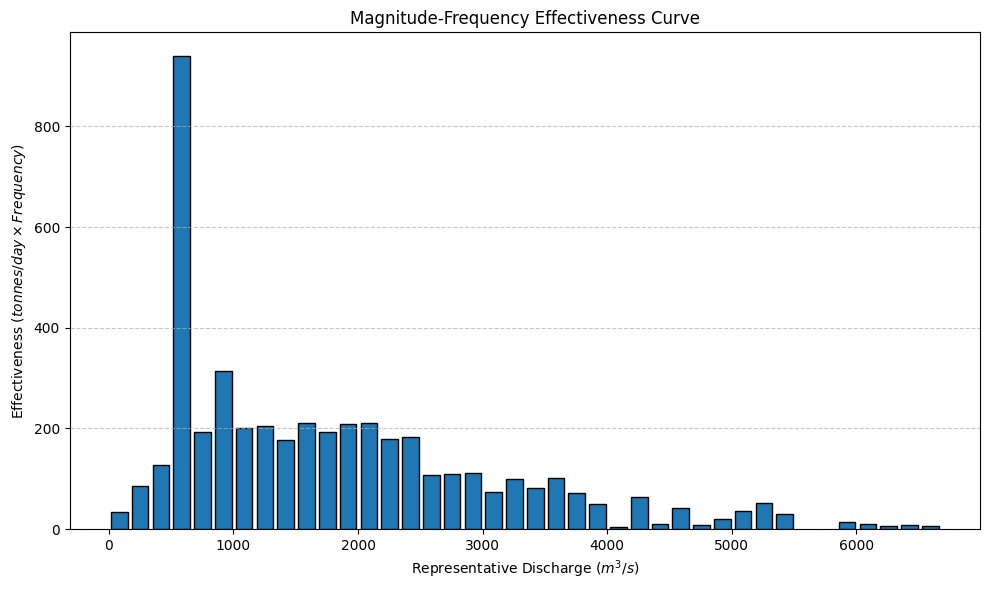

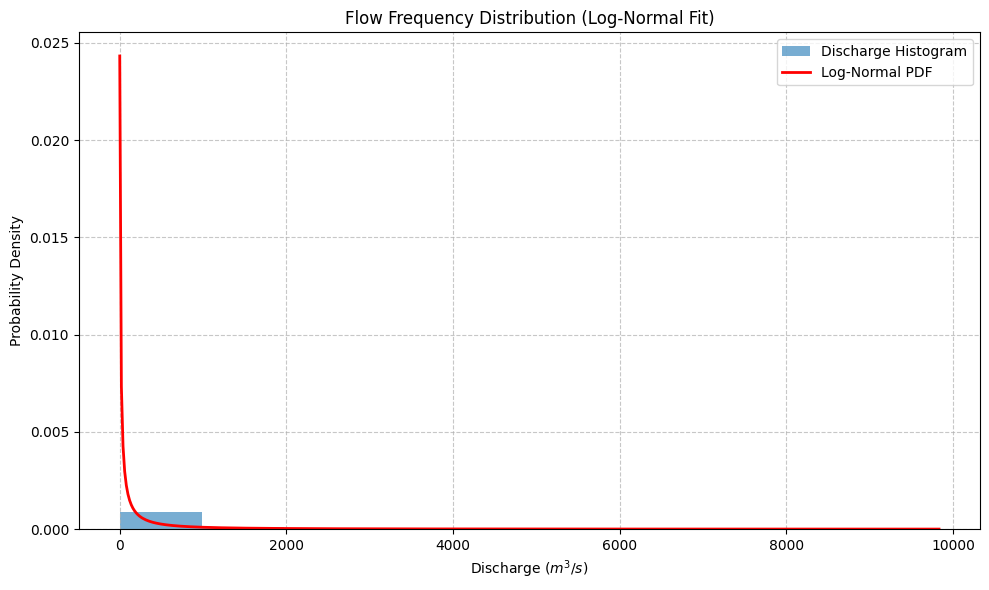

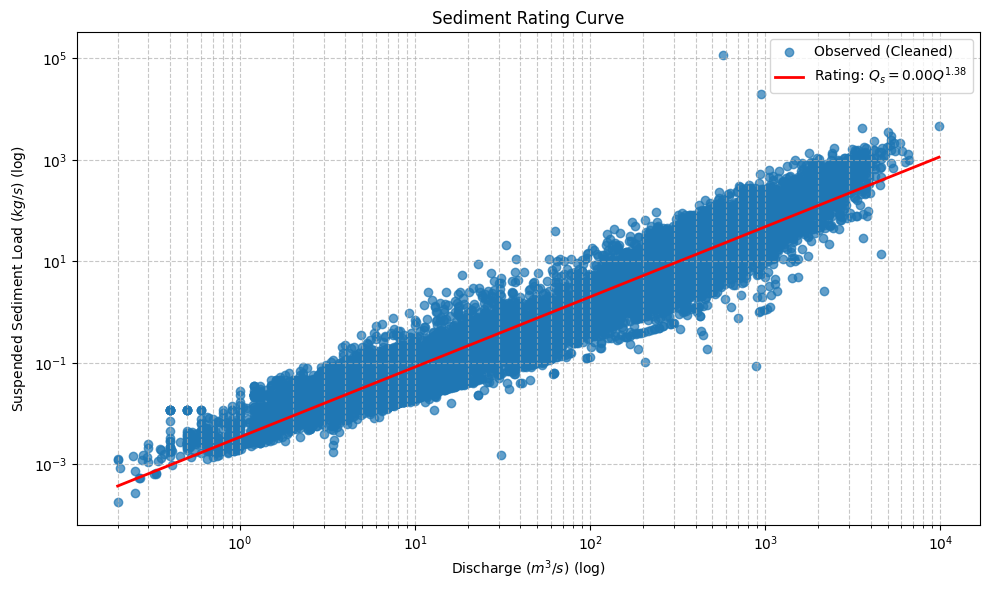

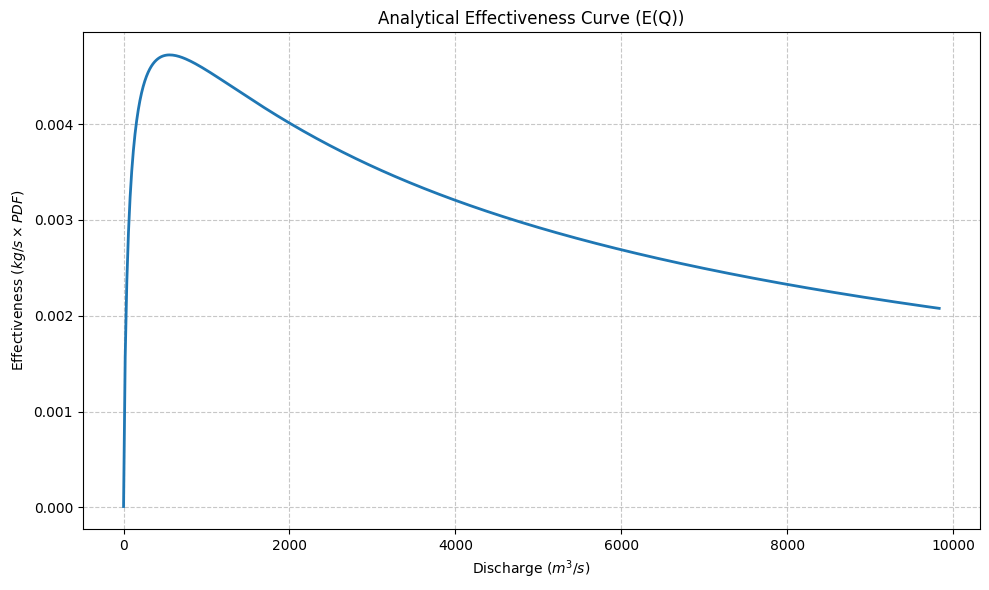

In [50]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Netravathi.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1980-06-09 08:00:00            65.0           0.0                 0.0   
1 1980-06-12 08:00:00            26.0           0.0                 0.0   
2 1980-06-13 08:00:00            20.0           0.0                 0.0   
3 1980-06-14 08:00:00            15.5           0.0                 0.0   
4 1980-06-15 08:00:00            13.0           0.0                 0.0   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0             0.0                           0.0                            0.0  
1             0.0                           0.0                            0.0  
2             0.0                           0.0                            0.0  
3             0.0                           0.0                            0.0  
4             0.0                           0.0                            0.0  

Comparison of user's Se

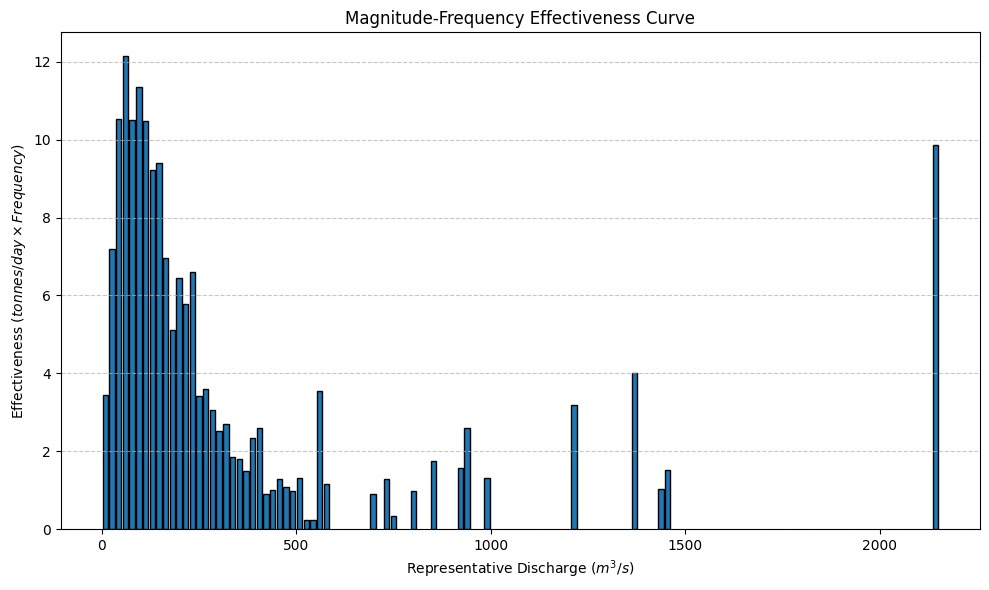

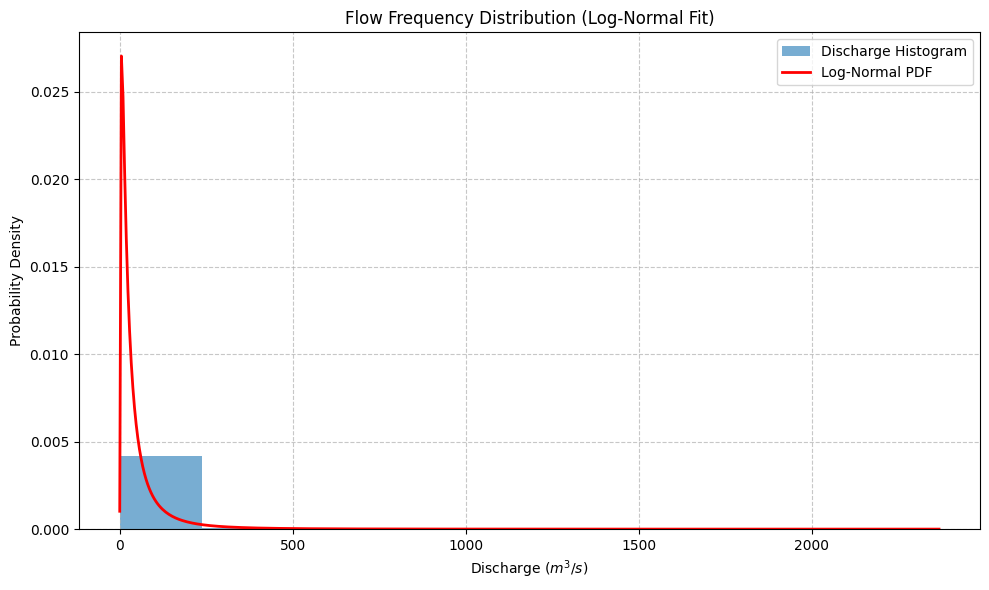

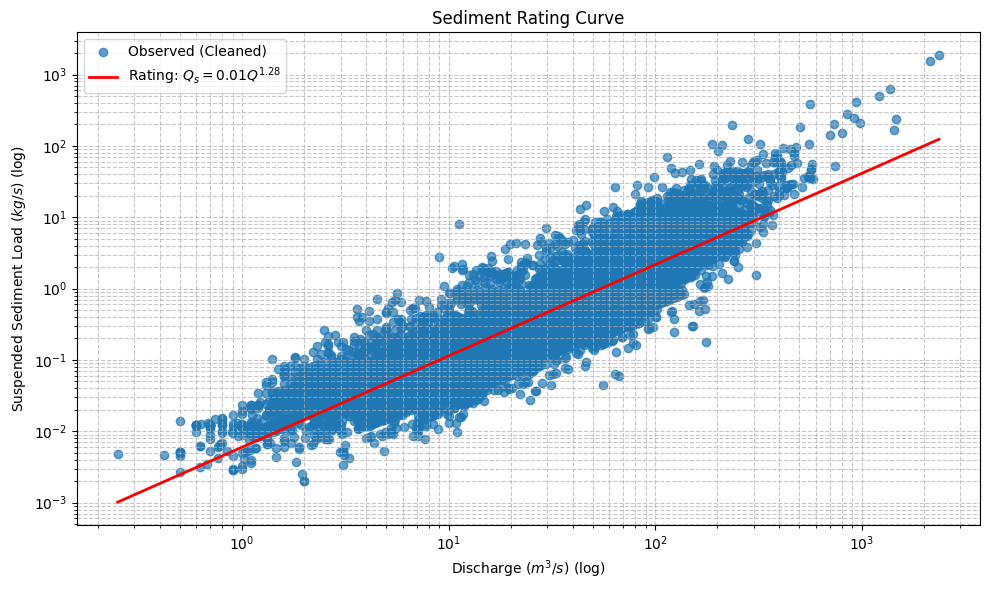

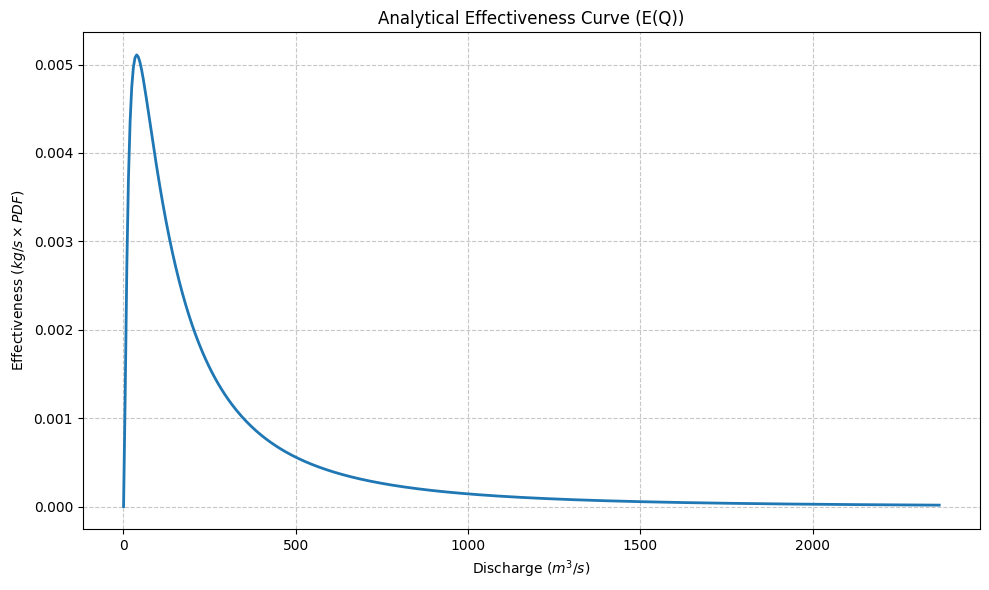

In [51]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Pattazhy.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1986-06-08 08:00:00             2.5        0.0000              0.0000   
1 1986-06-09 08:00:00             3.0        0.0000              0.0000   
2 1986-06-10 08:00:00             2.0        0.0000              0.0000   
3 1986-06-11 08:00:00             4.0        0.0000              0.0000   
4 1986-07-26 08:00:00           282.5        0.0142            346.5936   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0000                        0.0000                         0.0000  
1          0.0000                        0.0000                         0.0000  
2          0.0000                        0.0000                         0.0000  
3          0.0000                        0.0000                         0.0000  
4          0.0142                        4.0115                       346.5936  

Comparison of user's Se

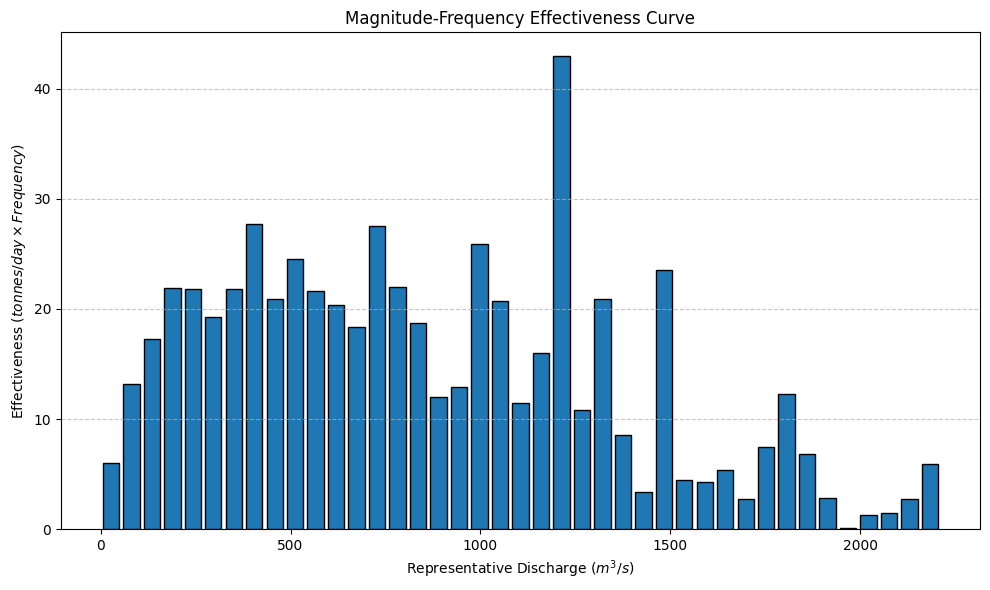

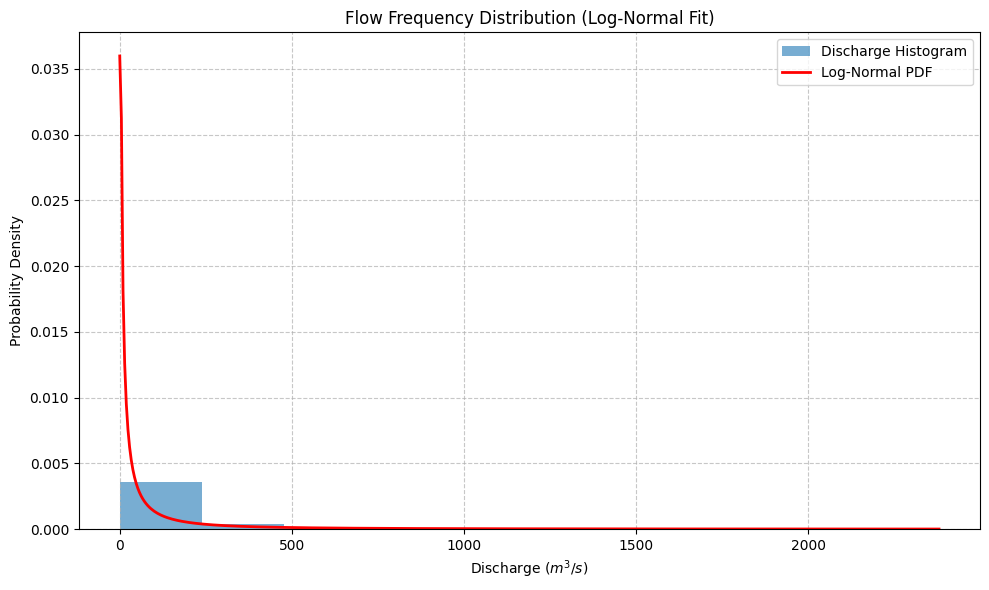

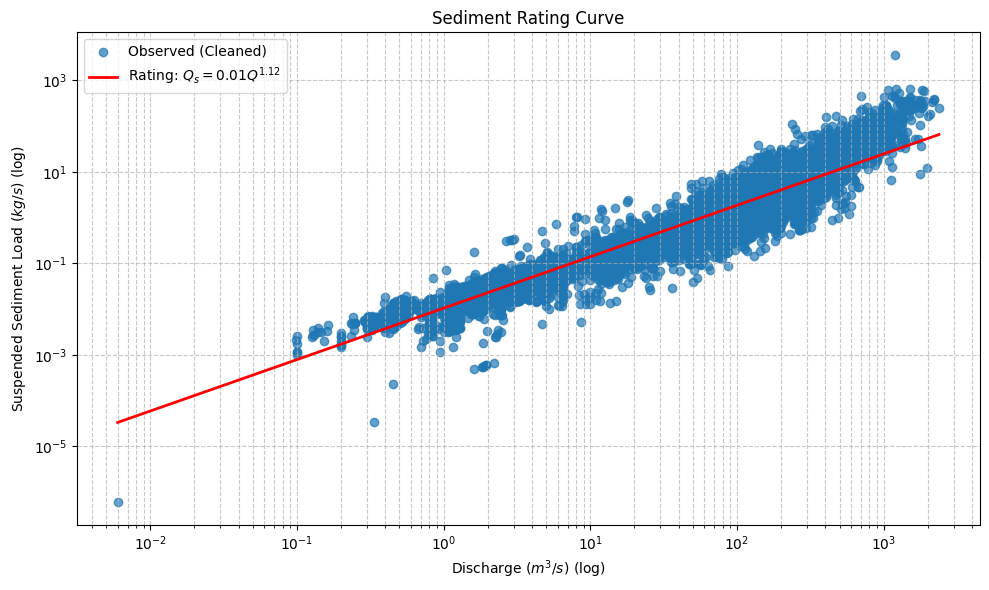

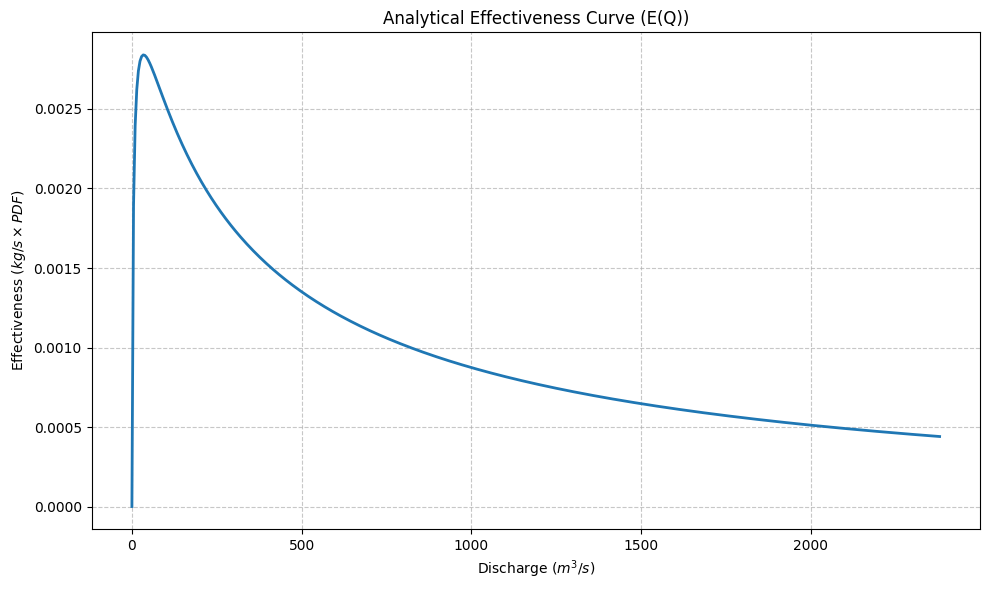

In [52]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Prumannu.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1986-06-08 08:00:00             4.0           0.0                 0.0   
1 1986-06-09 08:00:00             3.0           0.0                 0.0   
2 1986-06-15 08:00:00            25.0           0.0                 0.0   
3 1986-06-22 08:00:00            60.0           0.0                 0.0   
4 1986-06-29 08:00:00           402.5           0.0                 0.0   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0             0.0                           0.0                            0.0  
1             0.0                           0.0                            0.0  
2             0.0                           0.0                            0.0  
3             0.0                           0.0                            0.0  
4             0.0                           0.0                            0.0  

Comparison of user's Se

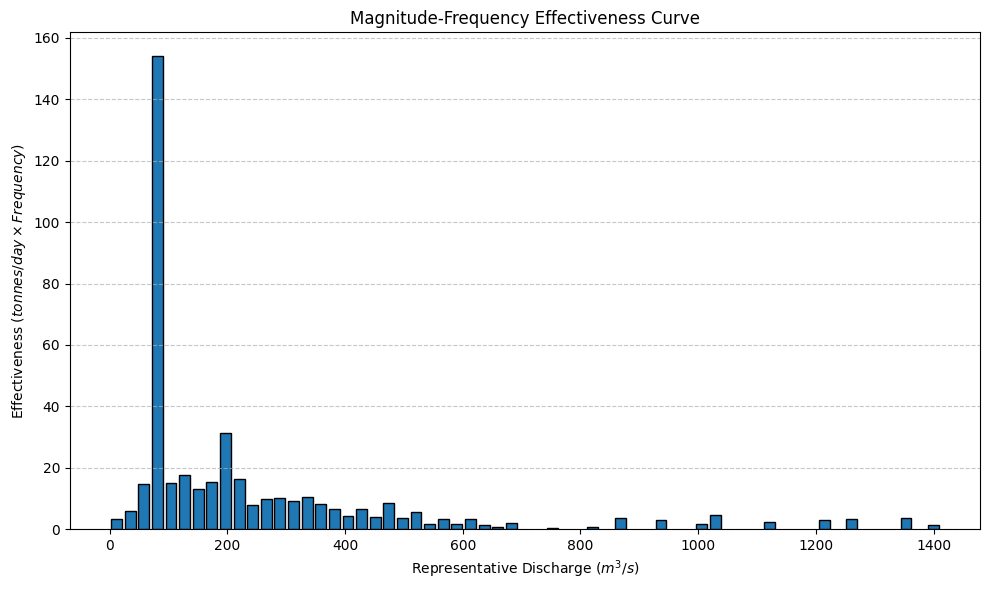

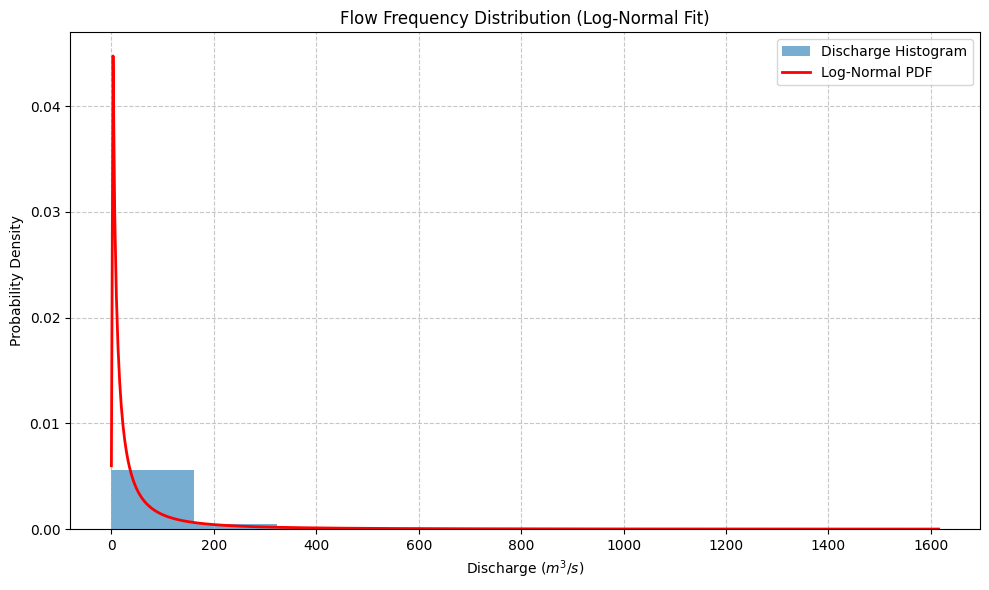

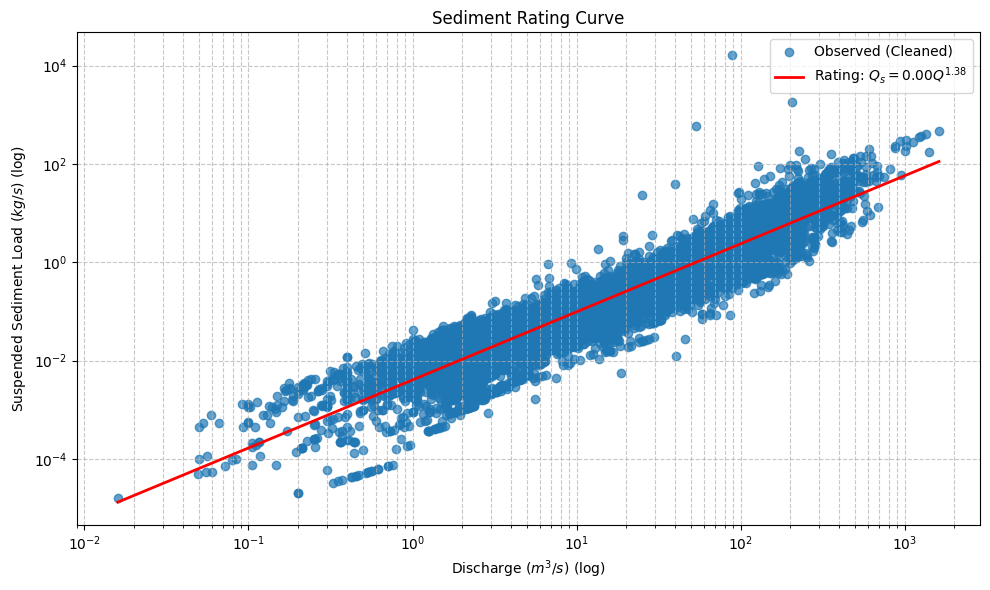

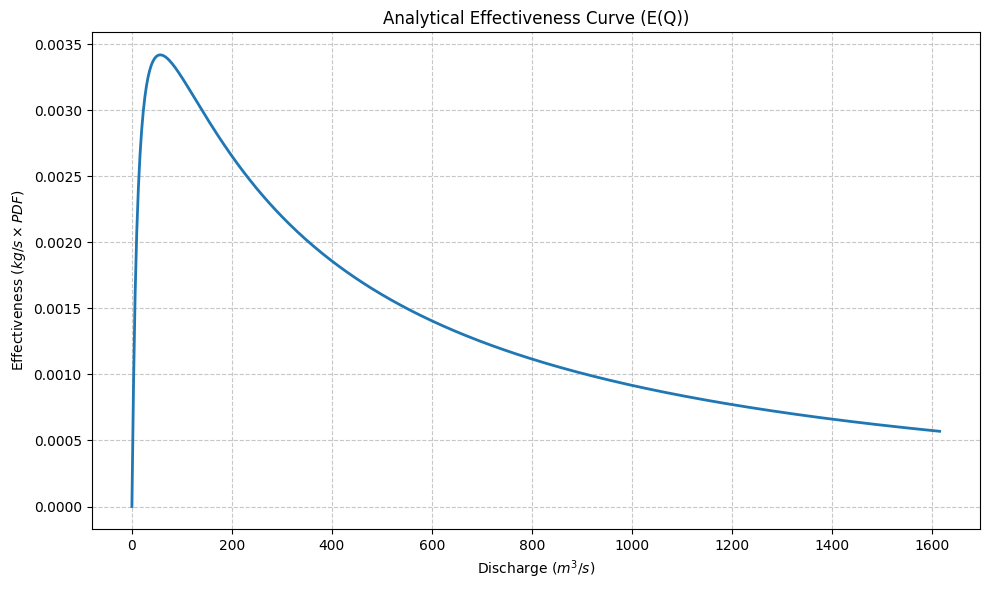

In [53]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Pulamanthole.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1979-02-10 08:00:00            61.0        0.0000             0.00000   
1 1979-02-11 08:00:00            61.0        0.0000             0.00000   
2 1979-02-18 08:00:00            62.5        0.0000             0.00000   
3 1979-02-25 08:00:00            62.0        0.0190           101.77920   
4 1979-03-04 08:00:00            61.0        0.0114            60.08256   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0          0.0000                        0.0000                        0.00000  
1          0.0000                        0.0000                        0.00000  
2          0.0000                        0.0000                        0.00000  
3          0.0190                        1.1780                      101.77920  
4          0.0114                        0.6954                       60.08256  

Comparison of user's Se

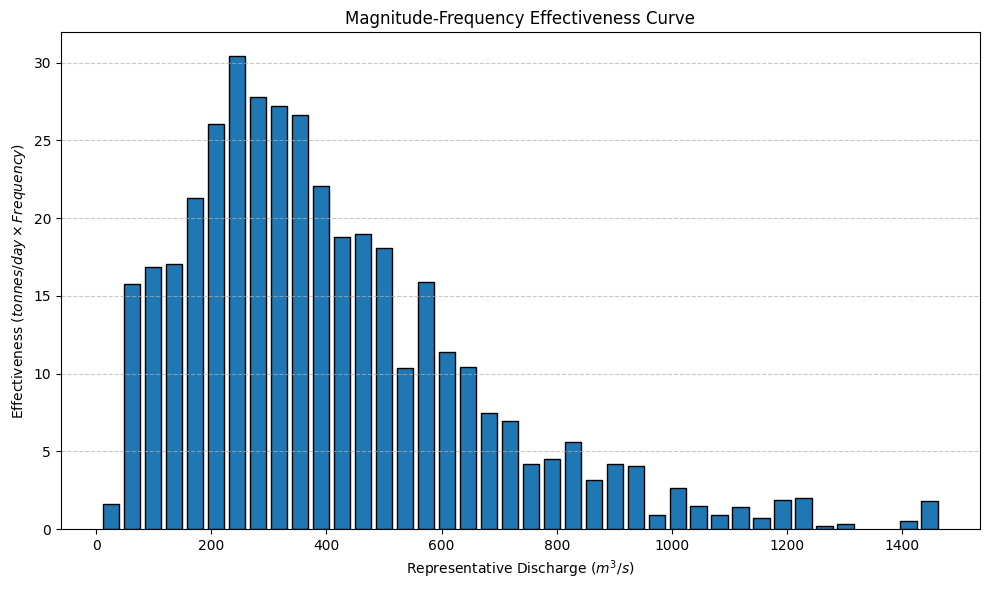

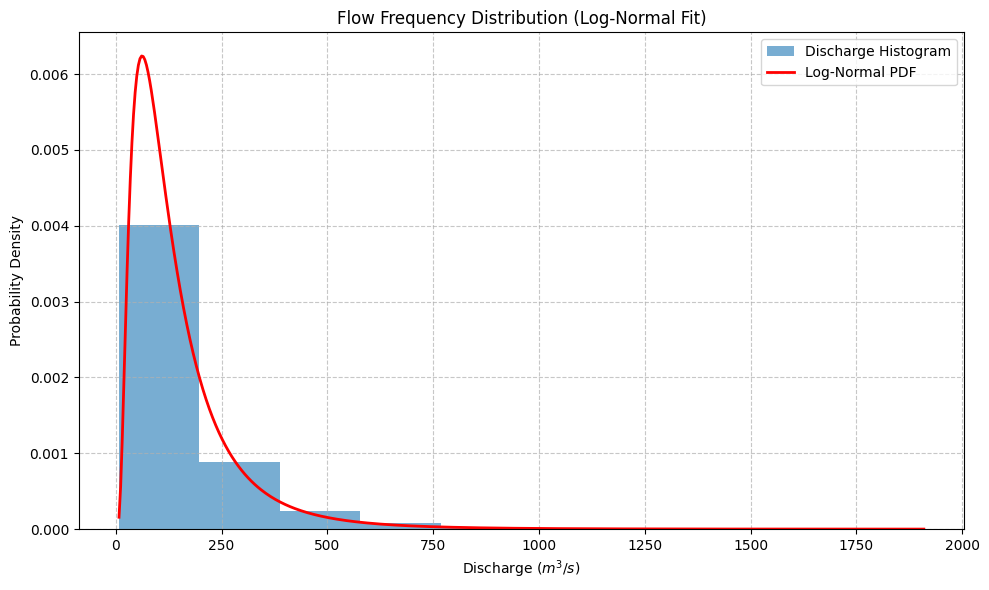

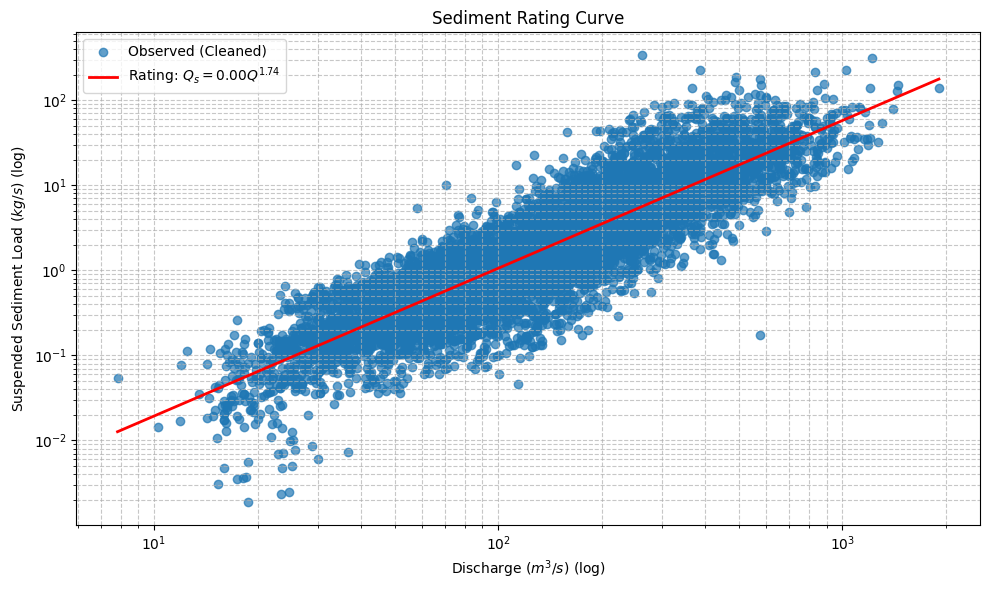

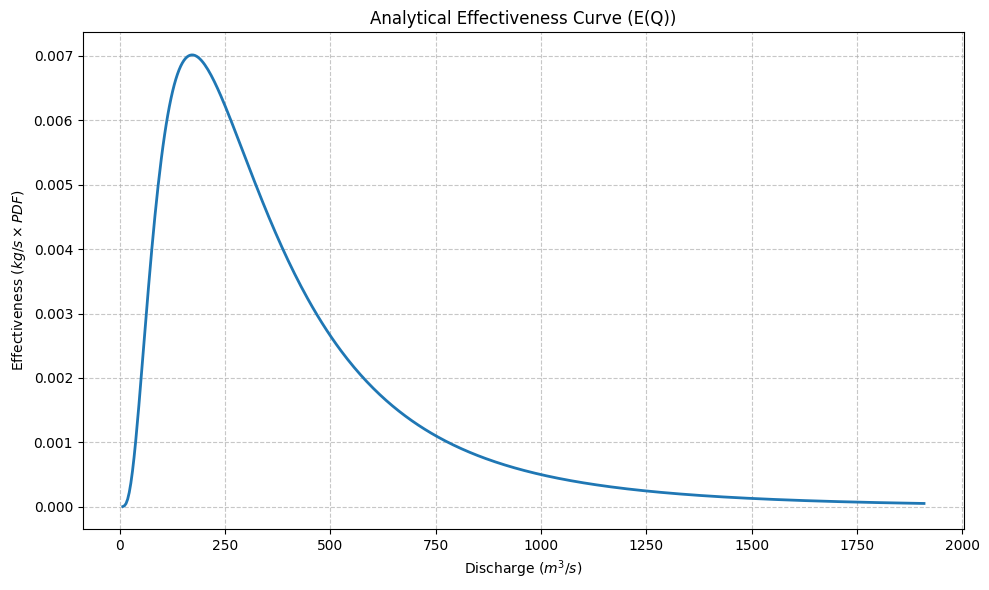

In [54]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Ramamanglam.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)

Data after initial preparation (head):
            Timestamp  Discharge_m3_s  Sediment_g_L  Sediment_tonne_day  \
0 1980-06-09 08:00:00            76.0           0.0                 0.0   
1 1980-06-15 08:00:00            15.0           0.0                 0.0   
2 1980-06-16 08:00:00            19.0           0.0                 0.0   
3 1980-06-22 08:00:00           125.0           0.0                 0.0   
4 1980-06-27 08:00:00           172.0           0.0                 0.0   

   Sediment_kg_m3  Suspended_Sediment_Load_kg_s  Calculated_Sediment_tonne_day  
0             0.0                           0.0                            0.0  
1             0.0                           0.0                            0.0  
2             0.0                           0.0                            0.0  
3             0.0                           0.0                            0.0  
4             0.0                           0.0                            0.0  

Comparison of user's Se

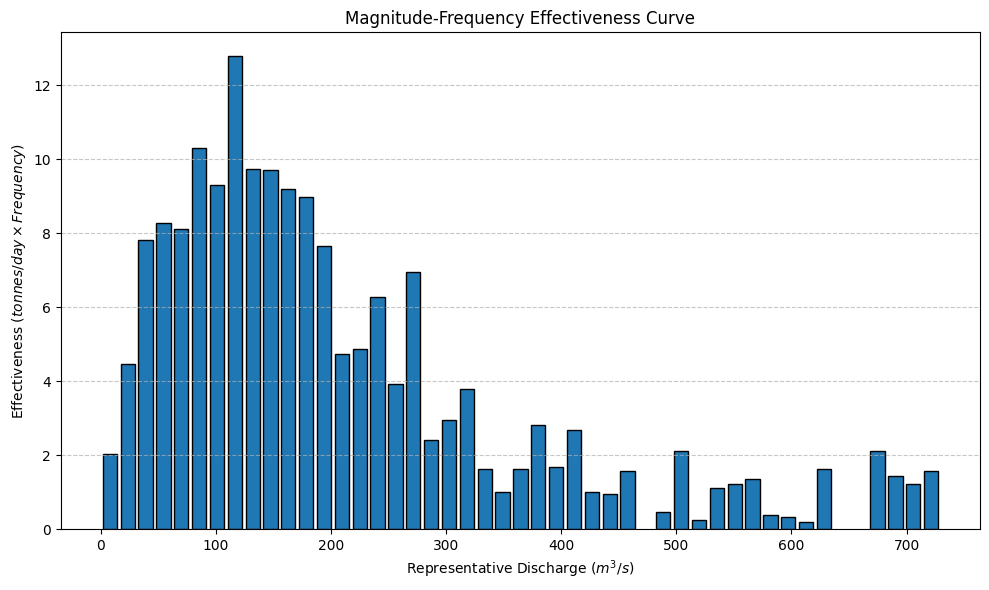

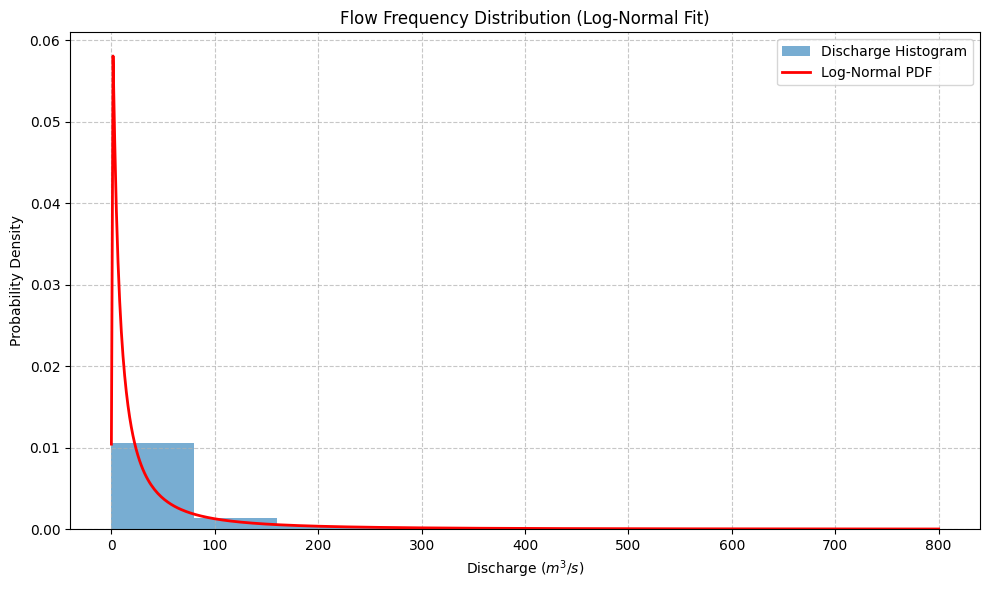

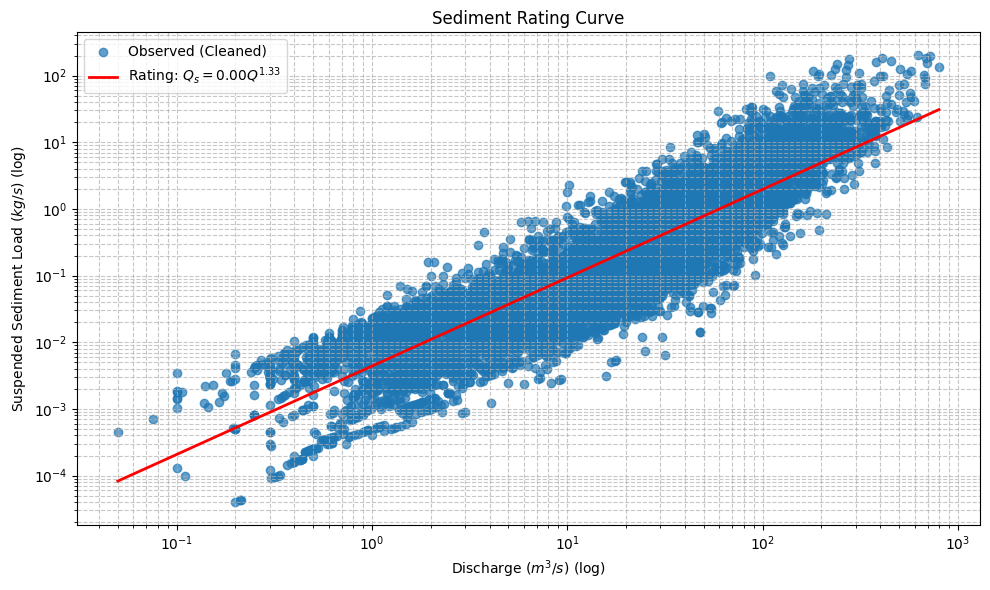

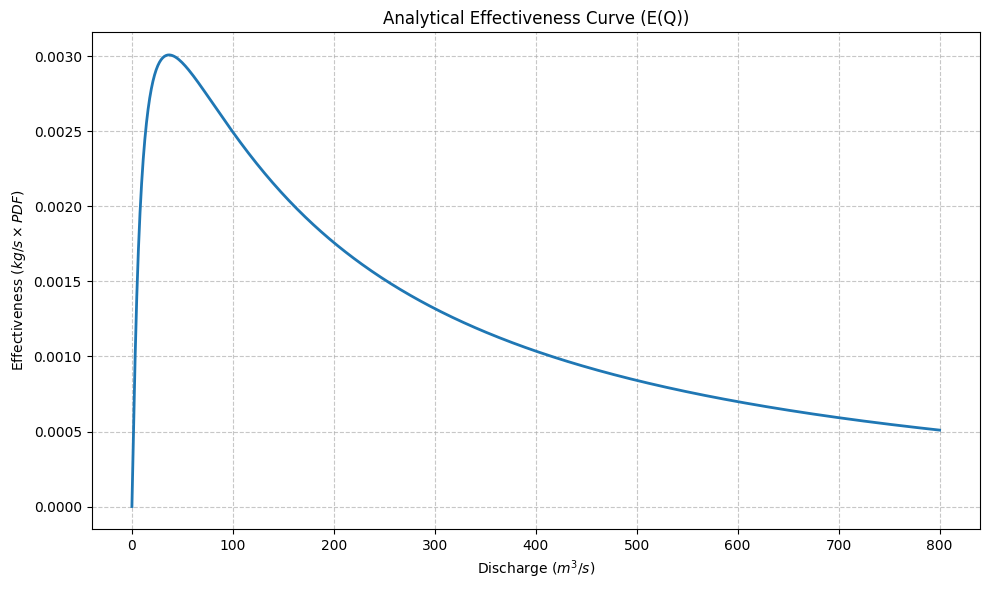

In [55]:
# qeff_from_single_csv_fixed.py
# pip install pandas numpy scipy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, linregress

CSV_FILE = "Merged_Thumpamon.csv"  # <-- change to your CSV filename

# ---------- helpers ----------
def infer_samples_per_year(ts: pd.Series) -> float:
    ts = pd.to_datetime(ts, errors="coerce").dropna()
    if ts.empty:
        return 365.0
    # FIX: Series already; no .to_series()
    counts = ts.groupby(ts.dt.year).size()
    return float(counts.mean()) if not counts.empty else 365.0

def q_return_lognormal(s, loc, scale, T_years, samples_per_year):
    if not samples_per_year or samples_per_year <= 0:
        samples_per_year = 365.0
    p = 1.0 - 1.0 / (T_years * samples_per_year)   # non-exceedance probability
    p = max(1e-6, min(1 - 1e-6, p))
    return float(lognorm.ppf(p, s, loc=loc, scale=scale))

# ---------- load ----------
df = pd.read_csv(CSV_FILE)

# --- Data Preparation (create necessary columns) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Convert Sediment_g_L to Sediment_kg_m3 (1 g/L = 1 kg/m3)
df['Sediment_kg_m3'] = df['Sediment_g_L'] * 1

# Calculate Suspended Sediment Load in kg/s
df['Suspended_Sediment_Load_kg_s'] = df['Discharge_m3_s'] * df['Sediment_kg_m3']

# Convert Suspended Sediment Load from kg/s to tonnes/day
df['Calculated_Sediment_tonne_day'] = df['Suspended_Sediment_Load_kg_s'] * 86400 / 1000

print("Data after initial preparation (head):")
print(df.head())

if 'Sediment_tonne_day' in df.columns:
    print("\nComparison of user's Sediment_tonne_day and calculated Sediment_tonne_day (head):")
    print(df[['Sediment_tonne_day', 'Calculated_Sediment_tonne_day']].head())

# Use the calculated column downstream (matches your logic regardless of match)
df['Sediment_tonne_day_used'] = df['Calculated_Sediment_tonne_day']

# --- Cleaning for analytical & histogram methods ---
df_analytical = df.copy()
df_analytical = df_analytical.dropna(subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s'])
df_analytical = df_analytical[df_analytical['Discharge_m3_s'] > 0]
df_analytical = df_analytical[df_analytical['Suspended_Sediment_Load_kg_s'] > 0]

skip_analytical = df_analytical.empty

# --- Magnitude-Frequency Histogram Approach ---
qeff_magnitude_frequency = np.nan
class_interval_size = np.nan

if not df_analytical.empty:
    print("\n--- Magnitude-Frequency Histogram Approach ---")

    # 1) Bin width = 0.25 * std (with your small-data fallback kept)
    discharge_std = df_analytical['Discharge_m3_s'].std()

    if discharge_std == 0:
        class_interval_size = 1.0
        print("Warning: Discharge standard deviation is zero. Using a default class interval size of 1.0 m³/s.")
    else:
        class_interval_size = 0.25 * discharge_std
    print(f"Standard deviation of discharge (cleaned data): {discharge_std:.2f} m³/s")
    print(f"Recommended class interval size (0.25 * S): {class_interval_size:.2f} m³/s")

    # 2) Bins
    min_discharge = df_analytical['Discharge_m3_s'].min()
    max_discharge = df_analytical['Discharge_m3_s'].max()

    if min_discharge == max_discharge:
        bins = [min_discharge, min_discharge + class_interval_size * 2]
    else:
        bins = np.arange(min_discharge, max_discharge + class_interval_size * 0.001, class_interval_size)

    # Your fallback for very small datasets
    if len(bins) < 5 and len(df_analytical) > 1:
        num_bins = max(5, int(np.ceil(np.sqrt(len(df_analytical)))))
        if num_bins < 2:
            num_bins = 2
        bins = np.linspace(min_discharge, max_discharge, num_bins)
        class_interval_size = bins[1] - bins[0]
    elif len(df_analytical) <= 1:
        print("Not enough data to create meaningful discharge classes for histogram.")
        if len(df_analytical) == 1:
            bins = [min_discharge, min_discharge + 1]
        else:
            bins = []

    if len(bins) > 1:
        print(f"Number of bins determined: {len(bins)-1}")
        print(f"Actual class interval size used: {class_interval_size:.2f} m³/s")

        # 3) Categorize and compute midpoints (keep Categorical intact)
        df_analytical['Discharge_Class'] = pd.cut(
            df_analytical['Discharge_m3_s'], bins=bins, include_lowest=True, right=False
        )
        cats = df_analytical['Discharge_Class'].cat.categories
        midpoint_map = {c: (c.left + c.right) / 2.0 for c in cats}

        # 4) Sum sediment per class (explicit names)
        sed_sum = (
            df_analytical.groupby('Discharge_Class', observed=True)['Sediment_tonne_day_used']
            .sum()
            .reset_index()
            .rename(columns={'Sediment_tonne_day_used': 'Sediment_sum_tpd'})
        )
        sed_sum['Representative_Discharge'] = sed_sum['Discharge_Class'].map(midpoint_map)

        # 5) Frequency per class via groupby (robust across pandas versions)
        freq = (
            df_analytical.groupby('Discharge_Class', observed=True).size()
            .reset_index(name='Count')
        )
        freq['Frequency'] = freq['Count'] / freq['Count'].sum()
        freq['Representative_Discharge'] = freq['Discharge_Class'].map(midpoint_map)

        # 6) Merge & compute E(Q)
        effectiveness_data = sed_sum.merge(
            freq[['Discharge_Class', 'Representative_Discharge', 'Frequency', 'Count']],
            on=['Discharge_Class', 'Representative_Discharge'],
            how='outer'
        )

        # Fill only numeric columns to avoid Categorical errors
        for col in ['Sediment_sum_tpd', 'Frequency', 'Count']:
            effectiveness_data[col] = effectiveness_data[col].fillna(0)

        effectiveness_data['Average_Sediment_Rate_tonne_day'] = np.where(
            effectiveness_data['Count'] > 0,
            effectiveness_data['Sediment_sum_tpd'] / effectiveness_data['Count'],
            0.0
        )
        effectiveness_data['E_Q'] = (
            effectiveness_data['Average_Sediment_Rate_tonne_day'] * effectiveness_data['Frequency']
        )

        effectiveness_data.dropna(subset=['Representative_Discharge'], inplace=True)
        effectiveness_data = effectiveness_data.sort_values('Representative_Discharge').reset_index(drop=True)

        print("\nEffectiveness Data (Class-Based):")
        print(effectiveness_data[['Representative_Discharge', 'Sediment_sum_tpd', 'Frequency', 'Count',
                                  'Average_Sediment_Rate_tonne_day', 'E_Q']])

        # 7) Plot (optional)
        plt.figure(figsize=(10, 6))
        if not effectiveness_data.empty:
            plt.bar(effectiveness_data['Representative_Discharge'], effectiveness_data['E_Q'],
                    width=class_interval_size * 0.8, edgecolor='black')
        plt.xlabel('Representative Discharge ($m^3/s$)')
        plt.ylabel('Effectiveness ($tonnes/day \\times Frequency$)')
        plt.title('Magnitude-Frequency Effectiveness Curve')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        #plt.savefig('magnitude_frequency_effectiveness_curve.png')

        # 8) Qeff from histogram
        if not effectiveness_data.empty and effectiveness_data['E_Q'].max() > 0:
            qeff_magnitude_frequency = float(
                effectiveness_data.loc[effectiveness_data['E_Q'].idxmax(), 'Representative_Discharge']
            )
            print(f"\nEffective Discharge (Qeff) by Magnitude-Frequency: {qeff_magnitude_frequency:.2f} m³/s")
        else:
            print("\nCould not determine Qeff by Magnitude-Frequency (E_Q all zero/NaN).")
    else:
        print("\nSkipping Magnitude-Frequency Histogram Approach: Not enough data after cleaning to create meaningful bins.")
else:
    print("\nSkipping Magnitude-Frequency Histogram Approach: df_analytical is empty after cleaning.")

# --- Analytical Approaches (using df_analytical) ---
qeff_analytical = np.nan
Q_1_5 = np.nan

if not skip_analytical:
    print("\n--- Analytical Approaches ---")

    # Ensure enough variation & clean data
    dfa2 = df_analytical.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['Discharge_m3_s', 'Suspended_Sediment_Load_kg_s']
    )

    if len(dfa2) >= 2 and dfa2['Discharge_m3_s'].nunique() >= 2:
        # 1) Log-normal fit to discharge
        s, loc, scale = lognorm.fit(dfa2['Discharge_m3_s'].values, floc=0)
        print(f"Log-normal parameters: s={s:.4f}, loc={loc:.4f}, scale={scale:.4f}")

        qmin, qmax = float(dfa2['Discharge_m3_s'].min()), float(dfa2['Discharge_m3_s'].max())
        if qmin < qmax:
            q_range = np.linspace(qmin, qmax, 500)
            pdf_q = lognorm.pdf(q_range, s, loc, scale)

            # 2) Rating curve Qs = a * Q^b via log–log regression
            log_q = np.log(dfa2['Discharge_m3_s'].values)
            log_qs = np.log(dfa2['Suspended_Sediment_Load_kg_s'].values)
            slope, intercept, r_value, p_value, std_err = linregress(log_q, log_qs)
            a_coef, b_exp = float(np.exp(intercept)), float(slope)
            print(f"Rating curve params: a={a_coef:.4f}, b={b_exp:.4f}, R^2={r_value**2:.4f}")

            qs_rating_curve = a_coef * (q_range ** b_exp)

            # 3) Effectiveness curve E(Q) = f(Q) * S(Q)
            effectiveness_curve_analytical = pdf_q * qs_rating_curve

            # 4) Analytical Qeff
            if effectiveness_curve_analytical.size > 0:
                idx = int(np.argmax(effectiveness_curve_analytical))
                qeff_analytical = float(q_range[idx])
                print(f"Analytical Qeff: {qeff_analytical:.2f} m³/s")

            # 5) Q_1.5 using emperical
            T = 1.5                       # return period (years)
            p = 1 - 1/T                   # non-exceedance prob for AM series = 1 - 1/T = 1/3
            # df has columns: Timestamp, Discharge_m3_s
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
            am = (df.dropna(subset=['Timestamp','Discharge_m3_s'])
                    .groupby(df['Timestamp'].dt.year)['Discharge_m3_s'].max()
                    .dropna())
            # Nonparametric estimate (linear quantile)
            Q_1_5 = am.quantile(p)     # p = 0.333...

            # Optional plots (kept from your script)
            plt.figure(figsize=(10, 6))
            plt.hist(dfa2['Discharge_m3_s'], bins=10, density=True, alpha=0.6, label='Discharge Histogram')
            plt.plot(q_range, pdf_q, 'r-', lw=2, label='Log-Normal PDF')
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Probability Density')
            plt.title('Flow Frequency Distribution (Log-Normal Fit)')
            plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('flow_frequency_distribution.png')

            plt.figure(figsize=(10, 6))
            plt.scatter(dfa2['Discharge_m3_s'], dfa2['Suspended_Sediment_Load_kg_s'], alpha=0.7, label='Observed (Cleaned)')
            plt.plot(q_range, qs_rating_curve, 'r-', lw=2, label=f'Rating: $Q_s = {a_coef:.2f}Q^{{{b_exp:.2f}}}$')
            plt.xscale('log'); plt.yscale('log')
            plt.xlabel('Discharge ($m^3/s$) (log)'); plt.ylabel('Suspended Sediment Load ($kg/s$) (log)')
            plt.title('Sediment Rating Curve')
            plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.7)
            plt.tight_layout()
            #plt.savefig('sediment_rating_curve.png')

            plt.figure(figsize=(10, 6))
            plt.plot(q_range, effectiveness_curve_analytical, lw=2)
            plt.xlabel('Discharge ($m^3/s$)'); plt.ylabel('Effectiveness ($kg/s \\times PDF$)')
            plt.title('Analytical Effectiveness Curve (E(Q))')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            #plt.savefig('analytical_effectiveness_curve.png')
        else:
            print("Analytical skipped: degenerate discharge range.")
    else:
        print("Analytical skipped: need at least 2 clean, positive points with varying discharge.")

# --- Q_bankfull (max discharge) ---
Q_bankfull = float(df['Discharge_m3_s'].max())

# --- Final Summary (one row) ---
summary = pd.DataFrame([{
    "file_name": CSV_FILE.replace("Merged_", "").replace(".csv", ""),
    "Qeff_hist": qeff_magnitude_frequency,
    "Qeff_analytical": qeff_analytical,
    "Q_1.5": Q_1_5,
    "Q_bankfull": Q_bankfull
}])

print("\n=== Summary ===")
print(summary)